## Exploratory Data Analysis 

This notebook provides dataset structure and quality inspection for each dataset, analyzing data types, missing values and duplicates rows.

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import warnings

# Configure pandas display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### 1. Inspection Function

The `inspect_dataset(df, dataset_name)` function inspects data types, missing values, unique values, sample entries, and duplicate rows for a given dataset.

In [3]:
def inspect_dataset(df, dataset_name="Dataset"):
    """
    Inspection of data types, missing values, unique counts, sample entries, and duplicate rows.
    """
    print(f"Inspection Report: {dataset_name}")
    print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns\n")
    
    # Column-level summary
    summary_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2) if len(df) > 0 else 0,
        'Unique Values': df.nunique(),
        'Sample Value': [df[col].dropna().iloc[0] if not df[col].dropna().empty else np.nan for col in df.columns]
    })
    
    # Duplicate rows count
    dup_count = df.duplicated().sum()
    dup_pct = (dup_count / len(df) * 100) if len(df) > 0 else 0
    print(f"\nDuplicate Rows: {dup_count:,}")

    
    df.info()
    return summary_df

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def univariate_analysis(df, categorical_cols, numerical_cols=None):
  """Performs univariate analysis with summary stats,

  value counts, and distribution plots.
  """
  # 1. Numerical & ID Summary Statistics
  if numerical_cols:
    print("=== Numerical Feature Summary ===")
    display(df[numerical_cols].describe())
    print("\n" + "=" * 50 + "\n")

  # 2. Categorical Distribution & Plots
  print("=== Categorical Feature Distributions ===")
  for col in categorical_cols:
    print(f"\nTop 10 Value Counts for: **{col}**")
    top_counts = df[col].value_counts().head(10)
    display(top_counts)

    # Plotting the distribution of top categories
    plt.figure(figsize=(10, 4))
    sns.countplot(
        data=df, y=col, order=df[col].value_counts().index[:10], palette="Blues_r"
    )
    plt.title(f"Top 10 Distribution - {col}", fontsize=12, fontweight="bold")
    plt.xlabel("Count", fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.show()
    print("-" * 50)


# Run the analysis on your dataset
categorical_cols = ["Bank Name", "Entity Name"]
numerical_cols = ["Bank ID"]


### 2. Importing Datasets

Load each dataset explicitly into its own variable.

In [4]:
# Load Accounts CSVs
hi_small_accounts = pd.read_csv("data/HI-Small_accounts.csv")
hi_medium_accounts = pd.read_csv("data/HI-Medium_accounts.csv")
li_small_accounts = pd.read_csv("data/LI-Small_accounts.csv")
li_medium_accounts = pd.read_csv("data/LI-Medium_accounts.csv")

# Load transaction samples (the complete files are large)
hi_small_trans = pd.read_csv("data/HI-Small_Trans.csv", nrows=100000)
hi_medium_trans = pd.read_csv("data/HI-Medium_Trans.csv", nrows=100000)
li_small_trans = pd.read_csv("data/LI-Small_Trans.csv", nrows=100000)
li_medium_trans = pd.read_csv("data/LI-Medium_Trans.csv", nrows=100000)

pattern_columns = [
    "Timestamp",
    "From Bank",
    "From Account",
    "To Bank",
    "To Account",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",
    "Pattern Type",
]


def load_pattern_dataset(path):
    """Load pattern transactions and retain their laundering-pattern labels."""
    import csv

    records = []
    pattern_type = None
    with open(path, encoding="utf-8") as pattern_file:
        for line in pattern_file:
            line = line.strip()
            if line.startswith("BEGIN LAUNDERING ATTEMPT - "):
                pattern_type = line.removeprefix("BEGIN LAUNDERING ATTEMPT - ").split(":", 1)[0].strip()
            elif line.startswith("END LAUNDERING ATTEMPT"):
                pattern_type = None
            elif line:
                row = next(csv.reader([line]))
                if len(row) != len(pattern_columns) - 1:
                    raise ValueError(f"Unexpected column count in {path}: {line}")
                if pattern_type is None:
                    raise ValueError(f"Pattern transaction found outside a pattern section in {path}")
                records.append([*row, pattern_type])

    patterns = pd.DataFrame(records, columns=pattern_columns)
    for column in ["Amount Received", "Amount Paid", "Is Laundering"]:
        patterns[column] = pd.to_numeric(patterns[column])
    return patterns


# Load pattern files as transaction-level datasets
hi_medium_patterns = load_pattern_dataset("data/HI-Medium_Patterns.txt")
hi_small_patterns = load_pattern_dataset("data/HI-Small_Patterns.txt")
li_medium_patterns = load_pattern_dataset("data/LI-Medium_Patterns.txt")
li_small_patterns = load_pattern_dataset("data/LI-Small_Patterns.txt")

account_categorical_cols = ["Bank Name", "Entity Name"]
account_numerical_cols = ["Bank ID"]
transaction_categorical_cols = [
    "Payment Format",
    "Payment Currency",
    "Receiving Currency",
    "Is Laundering",
]
transaction_numerical_cols = ["Amount Received", "Amount Paid"]
pattern_categorical_cols = [
    "Pattern Type",
    "Payment Format",
    "Payment Currency",
    "Receiving Currency",
    "Is Laundering",
]
pattern_numerical_cols = ["Amount Received", "Amount Paid"]


### 3. Dataset Inspections

### 3.1 Accounts Datasets


#### 3.1.1 `hi_small_accounts` (HI-Small Accounts)


In [5]:
display(inspect_dataset(hi_small_accounts, dataset_name="HI-Small Accounts"))


Inspection Report: HI-Small Accounts
Dataset Shape: 518,581 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Bank Name       518581 non-null  str  
 1   Bank ID         518581 non-null  int64
 2   Account Number  518581 non-null  str  
 3   Entity ID       518581 non-null  str  
 4   Entity Name     518581 non-null  str  
dtypes: int64(1), str(4)
memory usage: 19.8 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,str,0,0.0,20053,Portugal Bank #4507
Bank ID,int64,0,0.0,30470,331579
Account Number,str,0,0.0,518573,80B779D80
Entity ID,str,0,0.0,166207,80062E240
Entity Name,str,0,0.0,166207,Sole Proprietorship #50438


**Inspection summary:** HI-Small Accounts contains 518,581 rows and 5 columns, with no missing values or duplicate rows. `Account Number` and `Entity ID` are alphanumeric identifiers and correctly remain strings; converting them to integers would lose their identifier format.


=== Numerical Feature Summary ===


,Bank ID
count,518581.000000
mean,103425.510831
std,121479.549761
min,1.000000
25%,11107.000000
50%,32014.000000
75%,217096.000000
max,356303.000000




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


Bank Name
National Bank of Laramie       3797
National Bank of the East      3663
Japan Bank #0                  3051
Arbor Savings Bank             2894
National Bank of Pittsburgh    2683
Savings Bank of Fairfield      2642
First Bank of Tampa            2464
Savings Bank of Huron          2379
Savings Bank of Los Angeles    2052
Golden Bancorp                 1967
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


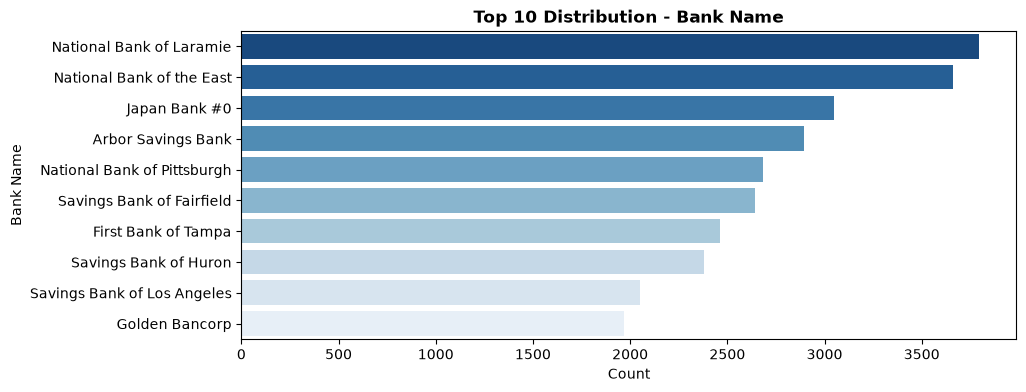

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Entity Name
Corporation #34854            7820
Country #1                    6677
Corporation #35871            4645
Sole Proprietorship #32941    3743
Corporation #33736            3402
Partnership #32618            3309
Partnership #33830            3057
Partnership #37705            2744
Partnership #36544            2705
Partnership #38444            2511
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


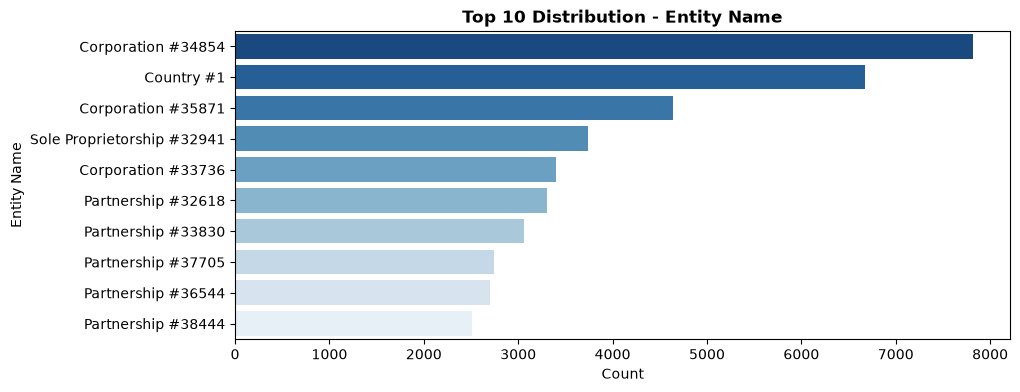

--------------------------------------------------


In [6]:
univariate_analysis(
    hi_small_accounts,
    categorical_cols=account_categorical_cols,
    numerical_cols=account_numerical_cols,
)


**Categorical balance:** Based on category proportions, `Bank Name` and `Entity Name` are broadly spread with no dominant category (the largest shares are 0.73% and 1.51%, respectively), although the high-cardinality distributions are not perfectly uniform.


#### 3.1.2 `hi_medium_accounts` (HI-Medium Accounts)


In [7]:
display(inspect_dataset(hi_medium_accounts, dataset_name="HI-Medium Accounts"))


Inspection Report: HI-Medium Accounts
Dataset Shape: 2,087,786 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 2087786 entries, 0 to 2087785
Data columns (total 5 columns):
 #   Column          Dtype
---  ------          -----
 0   Bank Name       str  
 1   Bank ID         int64
 2   Account Number  str  
 3   Entity ID       str  
 4   Entity Name     str  
dtypes: int64(1), str(4)
memory usage: 79.6 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,str,0,0.0,80180,China Bank #561
Bank ID,int64,0,0.0,122333,53267
Account Number,str,0,0.0,2087762,817D00980
Entity ID,str,0,0.0,668138,2AA1F24F180
Entity Name,str,0,0.0,668138,Corporation #183669


**Inspection summary:** HI-Medium Accounts contains 2,087,786 rows and 5 columns, with no missing values or duplicate rows. `Account Number` and `Entity ID` are alphanumeric identifiers and correctly remain strings; converting them to integers would lose their identifier format.


=== Numerical Feature Summary ===


,Bank ID
count,2.087786e+06
mean,6.321024e+05
std,9.703746e+05
min,0.000000e+00
25%,3.962400e+04
50%,2.037290e+05
75%,3.812120e+05
max,3.225455e+06




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


Bank Name
Savings Bank of Indianapolis    5635
Savings Bank of Seattle         5575
First Bank of Plattsburg        4983
First Bank of Miami             4887
Bank of Miami                   4722
National Bank of Plattsburg     4610
National Bank of New Orleans    4557
Bank of Huron                   4542
Savings Bank of Newbury         4416
National Bank of Los Angeles    4264
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


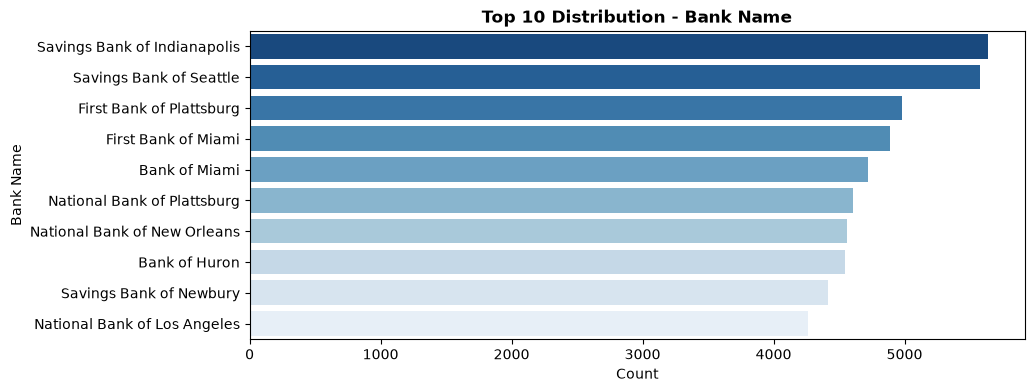

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Entity Name
Corporation #140481            8638
Partnership #139664            5639
Country #1                     4738
Partnership #130756            4714
Sole Proprietorship #145836    4369
Corporation #132573            4237
Sole Proprietorship #144757    4078
Partnership #133653            4058
Corporation #139355            3666
Corporation #140482            3290
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


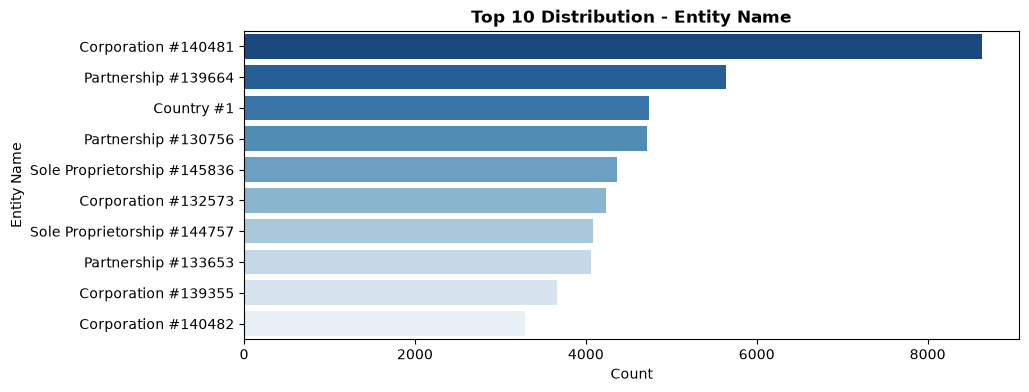

--------------------------------------------------


In [8]:
univariate_analysis(
    hi_medium_accounts,
    categorical_cols=account_categorical_cols,
    numerical_cols=account_numerical_cols,
)


**Categorical balance:** Based on category proportions, `Bank Name` and `Entity Name` are broadly spread with no dominant category (largest shares: 0.27% and 0.41%). The distributions are high-cardinality and not perfectly uniform.


#### 3.1.3 `li_small_accounts` (LI-Small Accounts)


In [9]:
display(inspect_dataset(li_small_accounts, dataset_name="LI-Small Accounts"))


Inspection Report: LI-Small Accounts
Dataset Shape: 712,688 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 712688 entries, 0 to 712687
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Bank Name       712688 non-null  str  
 1   Bank ID         712688 non-null  int64
 2   Account Number  712688 non-null  str  
 3   Entity ID       712688 non-null  str  
 4   Entity Name     712688 non-null  str  
dtypes: int64(1), str(4)
memory usage: 27.2 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,str,0,0.0,27652,China Bank #2820
Bank ID,int64,0,0.0,41815,314693
Account Number,str,0,0.0,712684,81B86A280
Entity ID,str,0,0.0,224931,800D8CCF0
Entity Name,str,0,0.0,224931,Corporation #41344


**Inspection summary:** LI-Small Accounts contains 712,688 rows and 5 columns, with no missing values or duplicate rows. `Account Number` and `Entity ID` are alphanumeric identifiers and correctly remain strings; converting them to integers would lose their identifier format.


=== Numerical Feature Summary ===


,Bank ID
count,712688.000000
mean,124162.203066
std,125918.383483
min,0.000000
25%,15680.000000
50%,57466.000000
75%,231905.000000
max,376967.000000




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


Bank Name
First Bank of Danbury            5918
Savings Bank of Madison          5679
National Bank of Columbus        2832
Savings Bank of the North        2762
Slovakia Bank #4                 2694
First Bank of the West           2582
Japan Bank #42                   2507
Savings Bank of Columbus         2499
National Bank of Seattle         2284
National Bank of Philadelphia    2248
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


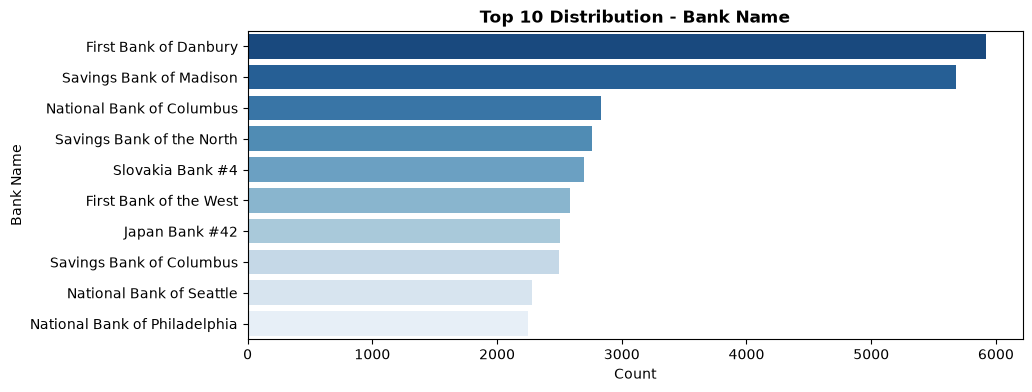

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Entity Name
Partnership #953              8899
Corporation #51259            5116
Corporation #47128            4795
Sole Proprietorship #49939    4793
Corporation #48389            4055
Sole Proprietorship #51014    3576
Sole Proprietorship #48001    3360
Partnership #23592            3013
Partnership #23467            2872
Corporation #48862            2775
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


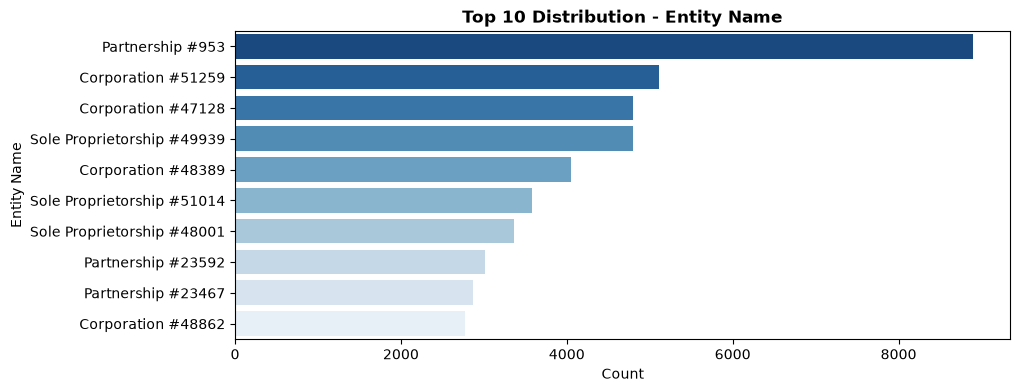

--------------------------------------------------


In [10]:
univariate_analysis(
    li_small_accounts,
    categorical_cols=account_categorical_cols,
    numerical_cols=account_numerical_cols,
)


**Categorical balance:** Based on category proportions, `Bank Name` and `Entity Name` are broadly spread with no dominant category (largest shares: 0.83% and 1.25%). The distributions are high-cardinality and not perfectly uniform.


#### 3.1.4 `li_medium_accounts` (LI-Medium Accounts)


In [11]:
display(inspect_dataset(li_medium_accounts, dataset_name="LI-Medium Accounts"))


Inspection Report: LI-Medium Accounts
Dataset Shape: 2,040,823 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 2040823 entries, 0 to 2040822
Data columns (total 5 columns):
 #   Column          Dtype
---  ------          -----
 0   Bank Name       str  
 1   Bank ID         int64
 2   Account Number  str  
 3   Entity ID       str  
 4   Entity Name     str  
dtypes: int64(1), str(4)
memory usage: 77.9 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,str,0,0.0,76636,Bank of New Orleans
Bank ID,int64,0,0.0,119617,9778
Account Number,str,0,0.0,2040789,834A31900
Entity ID,str,0,0.0,654133,2AA23456AF0
Entity Name,str,0,0.0,654133,Corporation #398


**Inspection summary:** LI-Medium Accounts contains 2,040,823 rows and 5 columns, with no missing values or duplicate rows. `Account Number` and `Entity ID` are alphanumeric identifiers and correctly remain strings; converting them to integers would lose their identifier format.


=== Numerical Feature Summary ===


,Bank ID
count,2.040823e+06
mean,6.092814e+05
std,9.544601e+05
min,0.000000e+00
25%,4.180500e+04
50%,1.924240e+05
75%,3.739785e+05
max,3.219766e+06




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


Bank Name
Bank of Lacrosse               5187
Bank of Los Angeles            5095
National Bank of Fort Wayne    4945
First Bank of Milford          4861
Bank of Tuscon                 4755
National Bank of Watertown     4608
Bank of Butte                  4605
Savings Bank of Chicago        4563
Bank of Denver                 4557
Fieldstone Trust Bank          4514
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


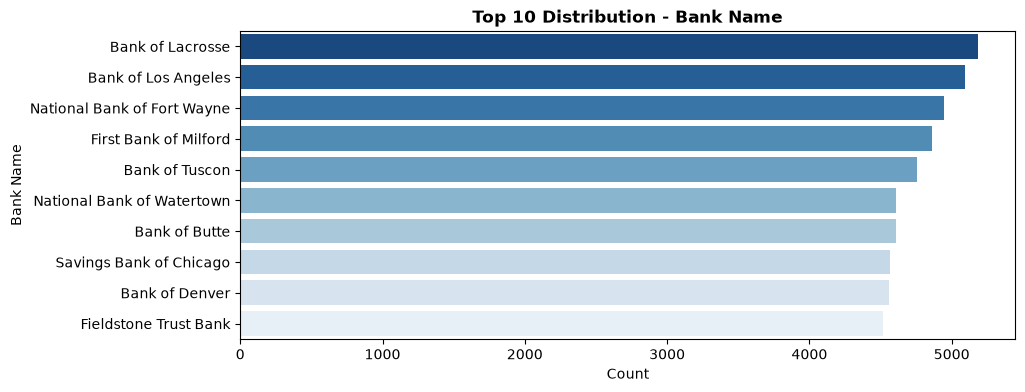

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Entity Name
Corporation #136151            10632
Corporation #128549             7754
Direct #1                       7302
Sole Proprietorship #142810     6056
Partnership #136131             6024
Partnership #140251             4982
Corporation #136020             4330
Corporation #132235             4014
Partnership #136221             3560
Corporation #137061             3305
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


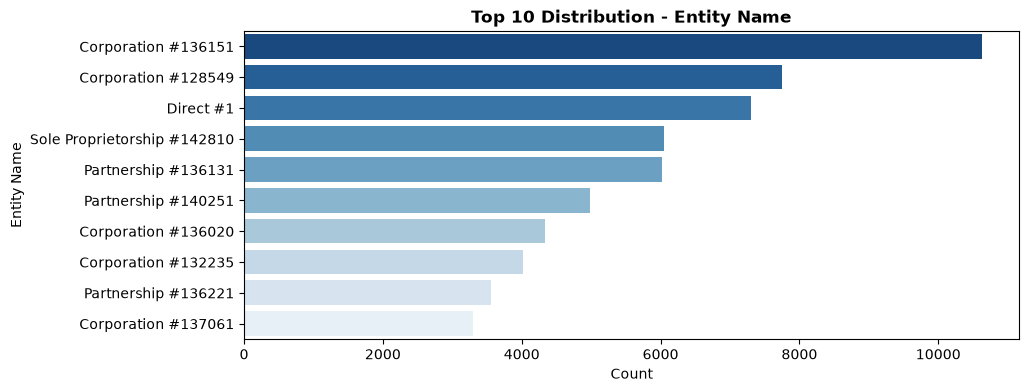

--------------------------------------------------


In [12]:
univariate_analysis(
    li_medium_accounts,
    categorical_cols=account_categorical_cols,
    numerical_cols=account_numerical_cols,
)


**Categorical balance:** Based on category proportions, `Bank Name` and `Entity Name` are broadly spread with no dominant category (largest shares: 0.25% and 0.52%). The distributions are high-cardinality and not perfectly uniform.


**Combining account datasets:** It may make sense to combine the four account datasets into one larger dataset, adding a `Type` column to record each row's source: `hi_small`, `li_small`, `hi_medium`, or `li_medium`. This would make it easier to analyze accounts together while retaining their dataset provenance.


### 3.2 Transaction Datasets


#### 3.2.1 `hi_small_trans` (HI-Small Transactions)


In [13]:
display(inspect_dataset(hi_small_trans, dataset_name="HI-Small Transactions"))


Inspection Report: HI-Small Transactions
Dataset Shape: 100,000 rows × 11 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Timestamp           100000 non-null  str    
 1   From Bank           100000 non-null  int64  
 2   Account             100000 non-null  str    
 3   To Bank             100000 non-null  int64  
 4   Account.1           100000 non-null  str    
 5   Amount Received     100000 non-null  float64
 6   Receiving Currency  100000 non-null  str    
 7   Amount Paid         100000 non-null  float64
 8   Payment Currency    100000 non-null  str    
 9   Payment Format      100000 non-null  str    
 10  Is Laundering       100000 non-null  int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 8.4 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,str,0,0.0,30,2022/09/01 00:20
From Bank,int64,0,0.0,4504,10
Account,str,0,0.0,74761,8000EBD30
To Bank,int64,0,0.0,3808,10
Account.1,str,0,0.0,73022,8000EBD30
Amount Received,float64,0,0.0,69408,3697.34
Receiving Currency,str,0,0.0,12,US Dollar
Amount Paid,float64,0,0.0,69655,3697.34
Payment Currency,str,0,0.0,12,US Dollar
Payment Format,str,0,0.0,7,Reinvestment


**Inspection summary:** The HI-Small Transactions sample contains 100,000 rows and 11 columns, with no missing values or duplicate rows. `Timestamp` is stored as text and should be parsed as datetime for time-based analysis. Account IDs are strings by design; amounts are floating-point values.


=== Numerical Feature Summary ===


,Amount Received,Amount Paid
count,1.000000e+05,1.000000e+05
mean,7.555877e+05,7.563408e+05
std,2.282190e+07,2.282226e+07
min,3.327000e-03,3.327000e-03
25%,2.044000e+01,2.045000e+01
50%,2.090525e+03,2.101495e+03
75%,2.391585e+04,2.395517e+04
max,5.351189e+09,5.351189e+09




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Payment Format**


Payment Format
Reinvestment    73296
Cheque           9393
Credit Card      9028
ACH              4436
Cash             2668
Wire             1149
Bitcoin            30
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


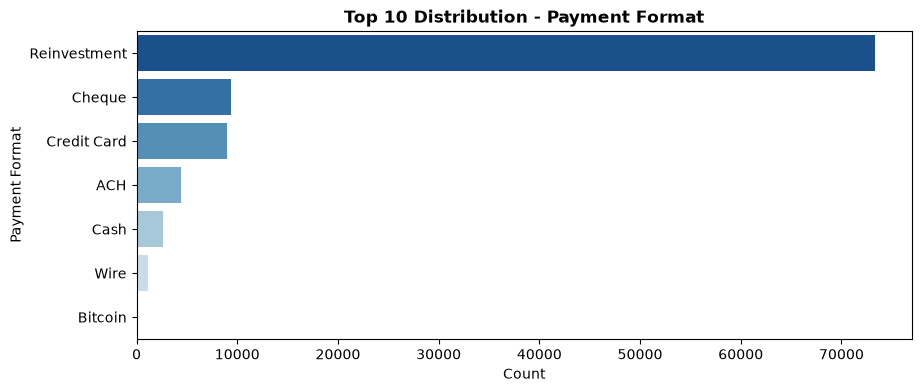

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            99627
Euro                   126
Yuan                    86
Canadian Dollar         32
Bitcoin                 29
Rupee                   29
UK Pound                23
Yen                     21
Australian Dollar        7
Mexican Peso             7
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


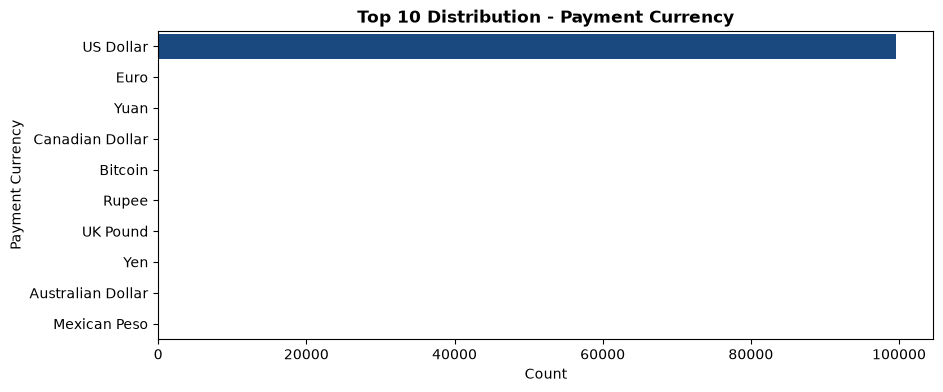

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar          99816
Euro                  71
Bitcoin               30
UK Pound              14
Yuan                  13
Rupee                 13
Canadian Dollar        9
Yen                    8
Mexican Peso           7
Ruble                  7
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


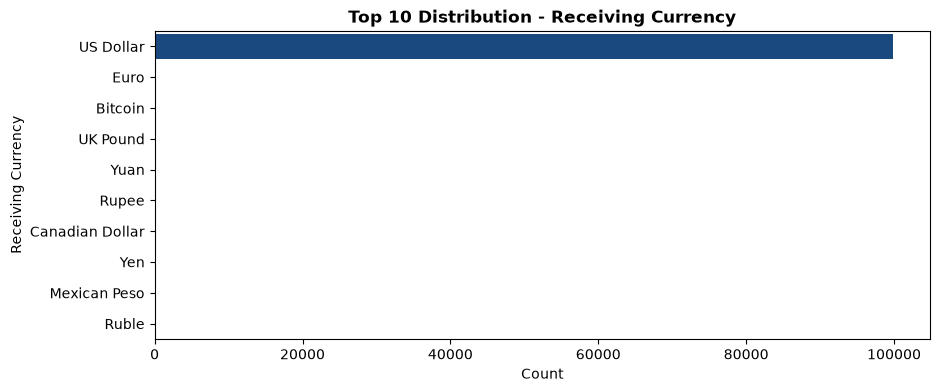

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    99995
1        5
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


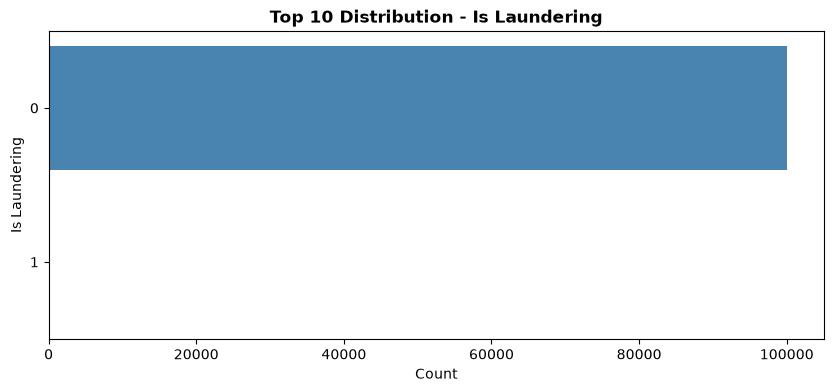

--------------------------------------------------


In [14]:
univariate_analysis(
    hi_small_trans,
    categorical_cols=transaction_categorical_cols,
    numerical_cols=transaction_numerical_cols,
)


**Categorical balance:** **imbalanced**. In this sample, Reinvestment accounts for 73.30% of `Payment Format`; US Dollar accounts for 99.63% of `Payment Currency` and 99.82% of `Receiving Currency`. `Is Laundering` is highly imbalanced: 99,995 legitimate vs 5 laundering transactions (0.005% positive).


#### 3.2.2 `hi_medium_trans` (HI-Medium Transactions)


In [15]:
display(inspect_dataset(hi_medium_trans, dataset_name="HI-Medium Transactions"))


Inspection Report: HI-Medium Transactions
Dataset Shape: 100,000 rows × 11 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Timestamp           100000 non-null  str    
 1   From Bank           100000 non-null  int64  
 2   Account             100000 non-null  str    
 3   To Bank             100000 non-null  int64  
 4   Account.1           100000 non-null  str    
 5   Amount Received     100000 non-null  float64
 6   Receiving Currency  100000 non-null  str    
 7   Amount Paid         100000 non-null  float64
 8   Payment Currency    100000 non-null  str    
 9   Payment Format      100000 non-null  str    
 10  Is Laundering       100000 non-null  int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 8.4 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,str,0,0.0,30,2022/09/01 00:17
From Bank,int64,0,0.0,4560,20
Account,str,0,0.0,74862,800104D70
To Bank,int64,0,0.0,4814,20
Account.1,str,0,0.0,74310,800104D70
Amount Received,float64,0,0.0,69822,6794.63
Receiving Currency,str,0,0.0,13,US Dollar
Amount Paid,float64,0,0.0,69996,6794.63
Payment Currency,str,0,0.0,13,US Dollar
Payment Format,str,0,0.0,7,Reinvestment


**Inspection summary:** The HI-Medium Transactions sample contains 100,000 rows and 11 columns, with no missing values or duplicate rows. `Timestamp` is stored as text and should be parsed as datetime for time-based analysis. Account IDs are strings by design; amounts are floating-point values.


=== Numerical Feature Summary ===


,Amount Received,Amount Paid
count,1.000000e+05,1.000000e+05
mean,1.150427e+06,1.142185e+06
std,3.057775e+07,2.988970e+07
min,1.000000e-02,1.000000e-02
25%,2.053000e+01,2.053000e+01
50%,2.514465e+03,2.512925e+03
75%,2.878403e+04,2.876994e+04
max,5.115429e+09,5.115429e+09




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Payment Format**


Payment Format
Reinvestment    73449
Cheque           9299
Credit Card      9083
ACH              4317
Cash             2666
Wire             1173
Bitcoin            13
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


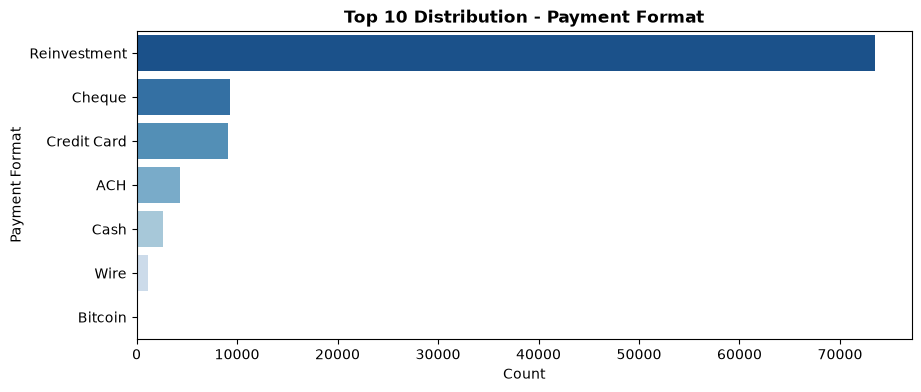

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            99752
Euro                   184
Yuan                    22
Bitcoin                 13
UK Pound                 9
Yen                      9
Canadian Dollar          3
Rupee                    2
Ruble                    2
Australian Dollar        1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


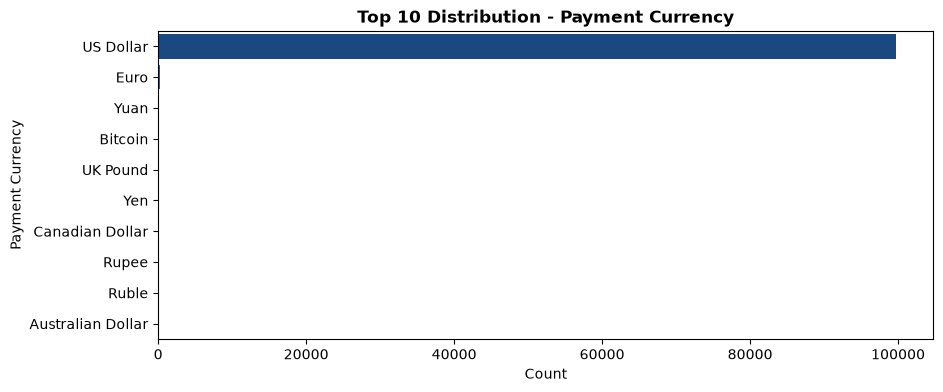

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            99859
Euro                    58
Yuan                    20
UK Pound                18
Bitcoin                 13
Yen                     10
Canadian Dollar          6
Rupee                    4
Ruble                    4
Australian Dollar        2
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


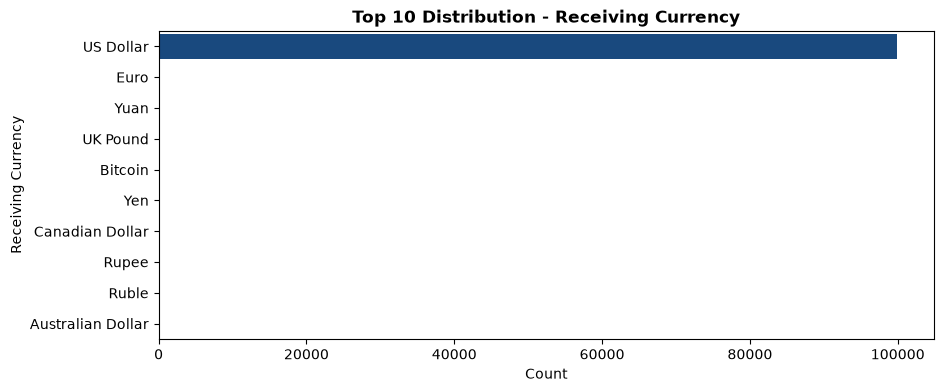

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    99999
1        1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


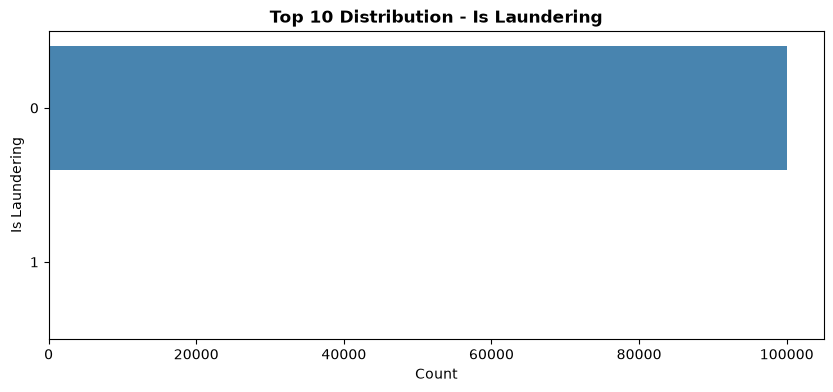

--------------------------------------------------


In [16]:
univariate_analysis(
    hi_medium_trans,
    categorical_cols=transaction_categorical_cols,
    numerical_cols=transaction_numerical_cols,
)


**Categorical balance:** **imbalanced**. In this sample, Reinvestment accounts for 73.45% of `Payment Format`; US Dollar accounts for 99.75% of `Payment Currency` and 99.86% of `Receiving Currency`. `Is Laundering` is highly imbalanced: 99,999 legitimate vs 1 laundering transaction (0.001% positive).


#### 3.2.3 `li_small_trans` (LI-Small Transactions)


In [17]:
display(inspect_dataset(li_small_trans, dataset_name="LI-Small Transactions"))


Inspection Report: LI-Small Transactions
Dataset Shape: 100,000 rows × 11 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Timestamp           100000 non-null  str    
 1   From Bank           100000 non-null  int64  
 2   Account             100000 non-null  str    
 3   To Bank             100000 non-null  int64  
 4   Account.1           100000 non-null  str    
 5   Amount Received     100000 non-null  float64
 6   Receiving Currency  100000 non-null  str    
 7   Amount Paid         100000 non-null  float64
 8   Payment Currency    100000 non-null  str    
 9   Payment Format      100000 non-null  str    
 10  Is Laundering       100000 non-null  int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 8.4 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,str,0,0.0,30,2022/09/01 00:08
From Bank,int64,0,0.0,4521,11
Account,str,0,0.0,74999,8000ECA90
To Bank,int64,0,0.0,3964,11
Account.1,str,0,0.0,73683,8000ECA90
Amount Received,float64,0,0.0,69794,3195403.0
Receiving Currency,str,0,0.0,12,US Dollar
Amount Paid,float64,0,0.0,70089,3195403.0
Payment Currency,str,0,0.0,12,US Dollar
Payment Format,str,0,0.0,7,Reinvestment


**Inspection summary:** The LI-Small Transactions sample contains 100,000 rows and 11 columns, with no missing values or duplicate rows. `Timestamp` is stored as text and should be parsed as datetime for time-based analysis. Account IDs are strings by design; amounts are floating-point values.


=== Numerical Feature Summary ===


,Amount Received,Amount Paid
count,1.000000e+05,1.000000e+05
mean,8.337064e+05,8.977980e+05
std,2.254556e+07,2.917045e+07
min,8.426000e-03,8.426000e-03
25%,2.071000e+01,2.071750e+01
50%,2.210100e+03,2.215990e+03
75%,2.433849e+04,2.435342e+04
max,4.310911e+09,5.708715e+09




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Payment Format**


Payment Format
Reinvestment    73396
Cheque           9328
Credit Card      9027
ACH              4433
Cash             2597
Wire             1202
Bitcoin            17
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


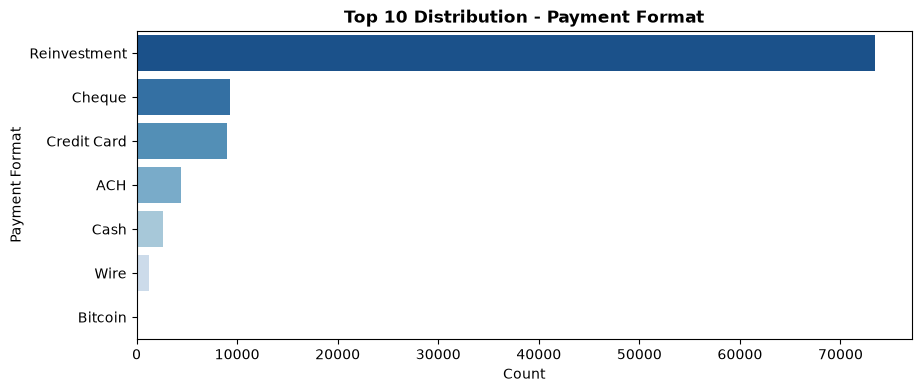

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar          99626
Euro                 220
Yuan                  80
Yen                   19
Bitcoin               17
UK Pound              15
Rupee                  8
Ruble                  6
Canadian Dollar        4
Brazil Real            2
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


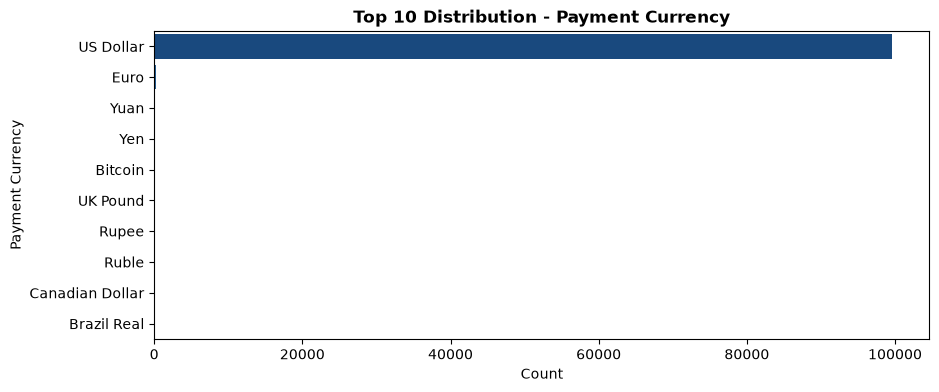

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            99857
Euro                    59
Bitcoin                 17
Yuan                    17
Yen                     16
UK Pound                14
Ruble                    7
Brazil Real              4
Canadian Dollar          4
Australian Dollar        2
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


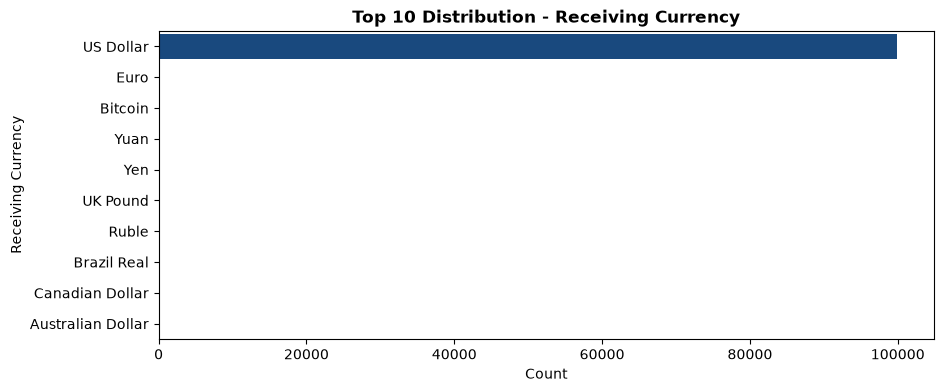

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    99997
1        3
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


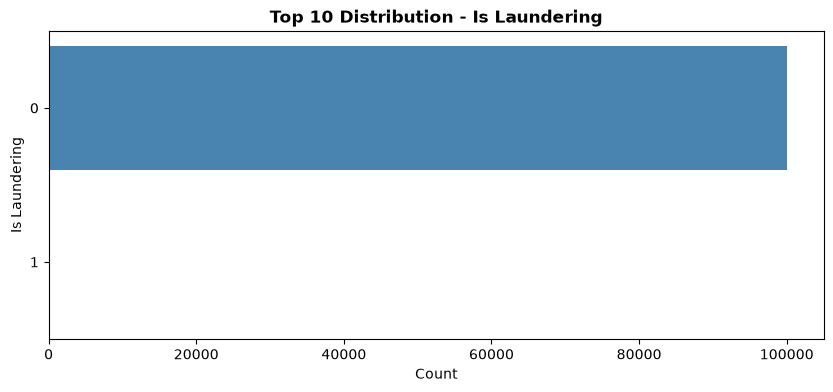

--------------------------------------------------


In [18]:
univariate_analysis(
    li_small_trans,
    categorical_cols=transaction_categorical_cols,
    numerical_cols=transaction_numerical_cols,
)


**Categorical balance:** **imbalanced**. In this sample, Reinvestment accounts for 73.40% of `Payment Format`; US Dollar accounts for 99.63% of `Payment Currency` and 99.86% of `Receiving Currency`. `Is Laundering` is highly imbalanced: 99,997 legitimate vs 3 laundering transactions (0.003% positive).


#### 3.2.4 `li_medium_trans` (LI-Medium Transactions)


In [19]:
display(inspect_dataset(li_medium_trans, dataset_name="LI-Medium Transactions"))


Inspection Report: LI-Medium Transactions
Dataset Shape: 100,000 rows × 11 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Timestamp           100000 non-null  str    
 1   From Bank           100000 non-null  int64  
 2   Account             100000 non-null  str    
 3   To Bank             100000 non-null  int64  
 4   Account.1           100000 non-null  str    
 5   Amount Received     100000 non-null  float64
 6   Receiving Currency  100000 non-null  str    
 7   Amount Paid         100000 non-null  float64
 8   Payment Currency    100000 non-null  str    
 9   Payment Format      100000 non-null  str    
 10  Is Laundering       100000 non-null  int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 8.4 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,str,0,0.0,30,2022/09/01 00:15
From Bank,int64,0,0.0,4524,20
Account,str,0,0.0,74821,800104D70
To Bank,int64,0,0.0,4796,20
Account.1,str,0,0.0,74411,800104D70
Amount Received,float64,0,0.0,69680,8095.07
Receiving Currency,str,0,0.0,13,US Dollar
Amount Paid,float64,0,0.0,69845,8095.07
Payment Currency,str,0,0.0,13,US Dollar
Payment Format,str,0,0.0,7,Reinvestment


**Inspection summary:** The LI-Medium Transactions sample contains 100,000 rows and 11 columns, with no missing values or duplicate rows. `Timestamp` is stored as text and should be parsed as datetime for time-based analysis. Account IDs are strings by design; amounts are floating-point values.


=== Numerical Feature Summary ===


,Amount Received,Amount Paid
count,1.000000e+05,1.000000e+05
mean,1.007544e+06,1.006304e+06
std,2.204640e+07,2.201919e+07
min,1.000000e-02,1.000000e-02
25%,2.042000e+01,2.043000e+01
50%,2.389840e+03,2.389505e+03
75%,2.775861e+04,2.775606e+04
max,3.624799e+09,3.624799e+09




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Payment Format**


Payment Format
Reinvestment    73630
Cheque           9271
Credit Card      9087
ACH              4205
Cash             2680
Wire             1105
Bitcoin            22
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


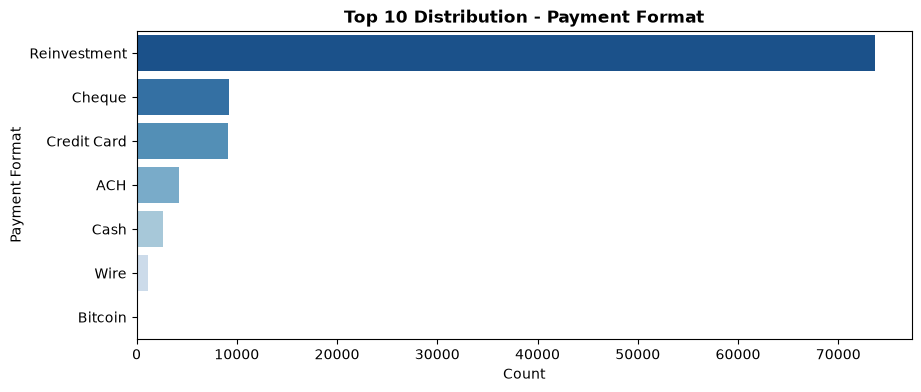

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            99758
Euro                   167
Yuan                    33
Bitcoin                 21
Yen                      7
Rupee                    3
Australian Dollar        3
UK Pound                 2
Canadian Dollar          2
Mexican Peso             1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


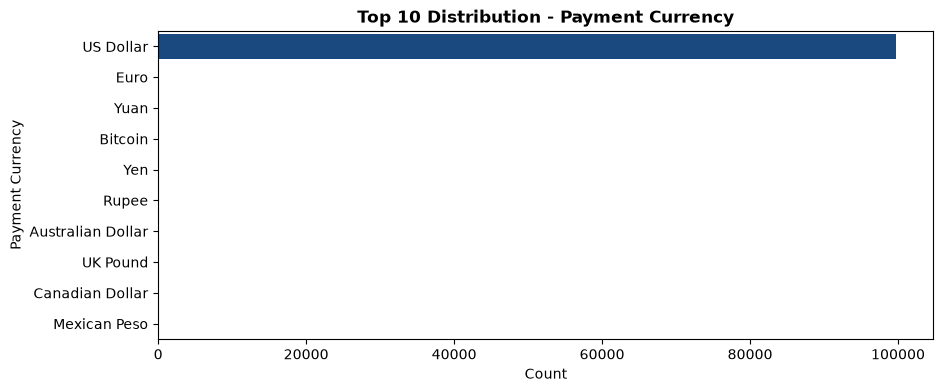

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            99874
Euro                    56
Bitcoin                 21
Yuan                    16
Yen                      7
Australian Dollar        6
UK Pound                 4
Canadian Dollar          4
Rupee                    4
Mexican Peso             2
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


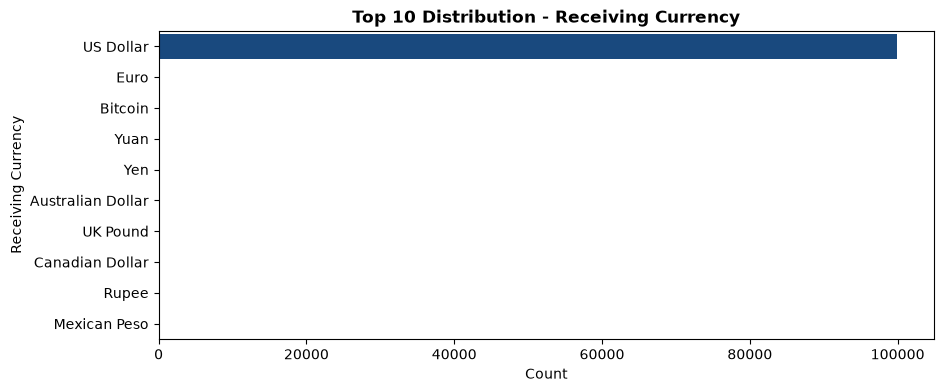

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    99997
1        3
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


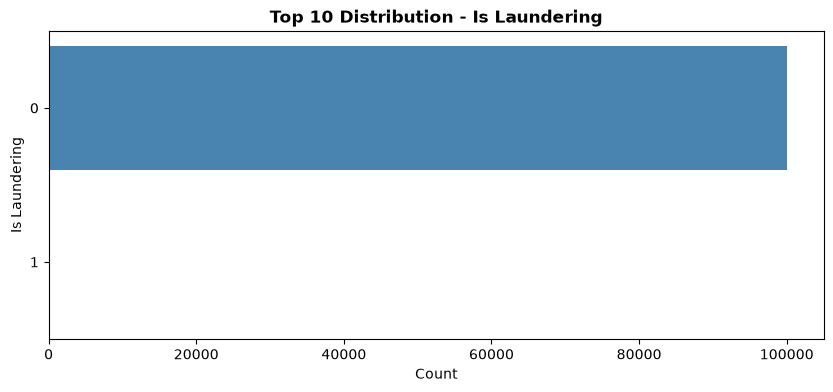

--------------------------------------------------


In [20]:
univariate_analysis(
    li_medium_trans,
    categorical_cols=transaction_categorical_cols,
    numerical_cols=transaction_numerical_cols,
)


**Categorical balance:** **imbalanced**. In this sample, Reinvestment accounts for 73.63% of `Payment Format`; US Dollar accounts for 99.76% of `Payment Currency` and 99.87% of `Receiving Currency`. `Is Laundering` is highly imbalanced: 99,997 legitimate vs 3 laundering transactions (0.003% positive).


**Combining transaction datasets:** It may make sense to combine the four transaction datasets into one larger dataset, adding a `Type` column to record each row's source: `hi_small`, `li_small`, `hi_medium`, or `li_medium`. This would simplify cross-dataset transaction analysis while preserving each row's source dataset.


### 3.3 Patterns Datasets


#### 3.3.1 `hi_medium_patterns` (HI-Medium Patterns)


In [21]:
display(inspect_dataset(hi_medium_patterns, dataset_name="HI-Medium Patterns"))


Inspection Report: HI-Medium Patterns
Dataset Shape: 22,743 rows × 12 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 22743 entries, 0 to 22742
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           22743 non-null  str    
 1   From Bank           22743 non-null  str    
 2   From Account        22743 non-null  str    
 3   To Bank             22743 non-null  str    
 4   To Account          22743 non-null  str    
 5   Amount Received     22743 non-null  float64
 6   Receiving Currency  22743 non-null  str    
 7   Amount Paid         22743 non-null  float64
 8   Payment Currency    22743 non-null  str    
 9   Payment Format      22743 non-null  str    
 10  Is Laundering       22743 non-null  int64  
 11  Pattern Type        22743 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 2.1 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,str,0,0.0,14703,2022/09/01 05:14
From Bank,str,0,0.0,2353,00952
From Account,str,0,0.0,14836,8139F54E0
To Bank,str,0,0.0,2346,0111632
To Account,str,0,0.0,14546,8062C56E0
Amount Received,float64,0,0.0,21886,5331.44
Receiving Currency,str,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,21886,5331.44
Payment Currency,str,0,0.0,15,US Dollar
Payment Format,str,0,0.0,2,ACH


**Inspection summary:** HI-Medium Patterns contains 22,743 rows and 12 columns, with no missing values or duplicate rows. It has 8 pattern types. Timestamps are stored as text and should be parsed as datetime for time-based analysis; bank/account IDs remain strings to preserve identifier formatting.


=== Numerical Feature Summary ===


,Amount Received,Amount Paid
count,2.274300e+04,2.274300e+04
mean,7.331469e+07,7.331469e+07
std,6.196314e+09,6.196314e+09
min,1.110412e+00,1.110412e+00
25%,5.825595e+03,5.825595e+03
50%,1.152275e+04,1.152275e+04
75%,1.835655e+04,1.835655e+04
max,9.062701e+11,9.062701e+11




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Pattern Type**


Pattern Type
GATHER-SCATTER    4289
SCATTER-GATHER    3988
STACK             3986
FAN-IN            2315
CYCLE             2235
BIPARTITE         2135
FAN-OUT           2128
RANDOM            1667
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


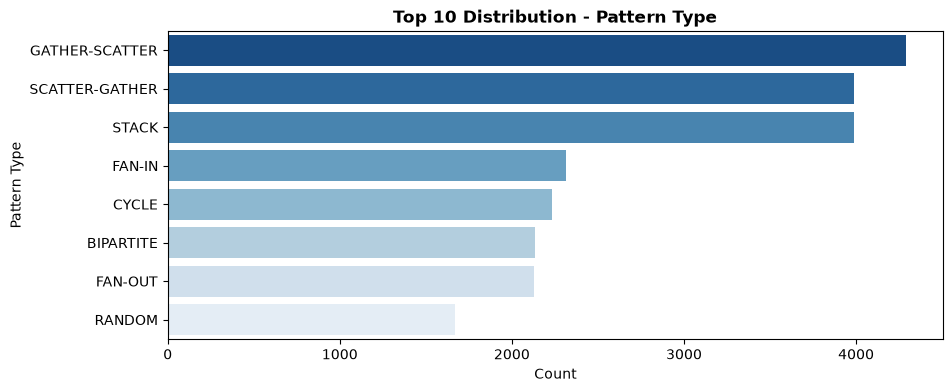

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
ACH        22740
Bitcoin        3
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


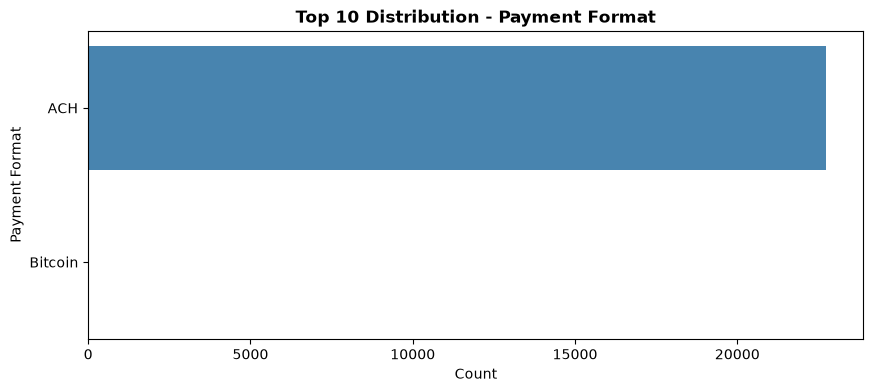

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            9714
Euro                 6792
Yuan                 1882
UK Pound             1262
Ruble                1087
Yen                   819
Rupee                 552
Australian Dollar     341
Canadian Dollar       141
Shekel                114
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


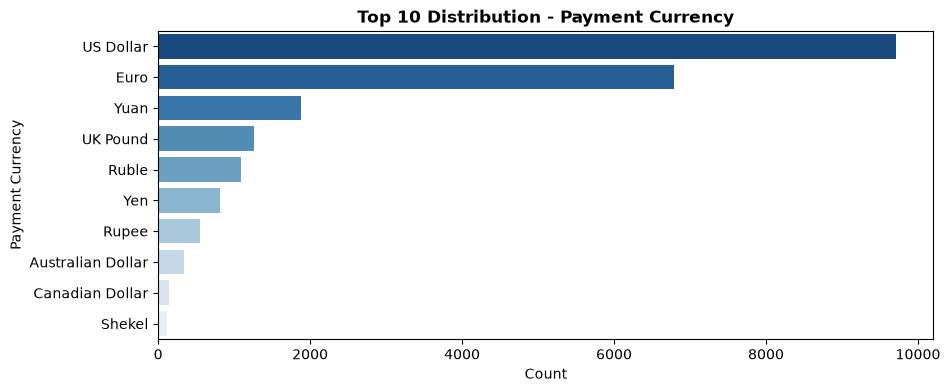

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            9714
Euro                 6792
Yuan                 1882
UK Pound             1262
Ruble                1087
Yen                   819
Rupee                 552
Australian Dollar     341
Canadian Dollar       141
Shekel                114
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


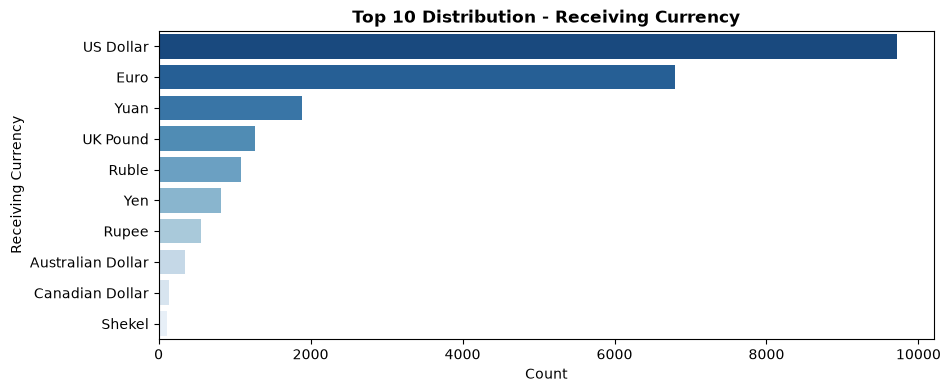

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
1    22743
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


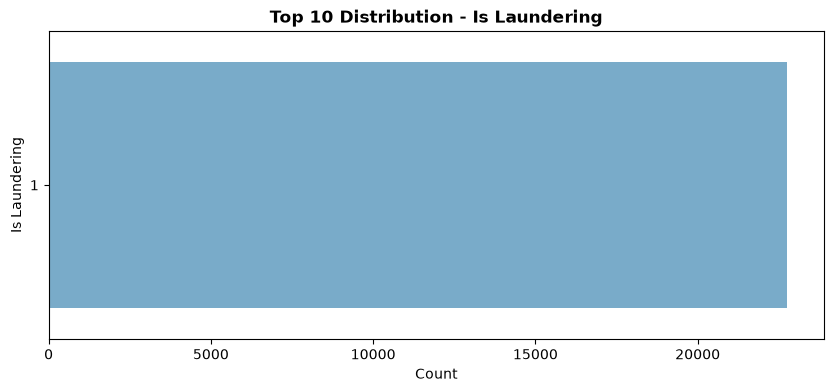

--------------------------------------------------


In [22]:
univariate_analysis(
    hi_medium_patterns,
    categorical_cols=pattern_categorical_cols,
    numerical_cols=pattern_numerical_cols,
)


**Categorical balance:** `Pattern Type` is relatively well spread across its 8 categories (largest: GATHER-SCATTER at 18.86%), though not perfectly uniform. `Payment Format` is imbalanced (ACH 99.99%); currency is moderately imbalanced (US Dollar 42.71%). `Is Laundering` cannot be balanced within this pattern-only data: every row is 1, so there are no legitimate examples.


#### 3.3.2 `hi_small_patterns` (HI-Small Patterns)


In [23]:
display(inspect_dataset(hi_small_patterns, dataset_name="HI-Small Patterns"))


Inspection Report: HI-Small Patterns
Dataset Shape: 3,209 rows × 12 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 3209 entries, 0 to 3208
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           3209 non-null   str    
 1   From Bank           3209 non-null   str    
 2   From Account        3209 non-null   str    
 3   To Bank             3209 non-null   str    
 4   To Account          3209 non-null   str    
 5   Amount Received     3209 non-null   float64
 6   Receiving Currency  3209 non-null   str    
 7   Amount Paid         3209 non-null   float64
 8   Payment Currency    3209 non-null   str    
 9   Payment Format      3209 non-null   str    
 10  Is Laundering       3209 non-null   int64  
 11  Pattern Type        3209 non-null   str    
dtypes: float64(2), int64(1), str(9)
memory usage: 301.0 KB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,str,0,0.0,2888,2022/09/01 00:06
From Bank,str,0,0.0,781,021174
From Account,str,0,0.0,2071,800737690
To Bank,str,0,0.0,780,012
To Account,str,0,0.0,2064,80011F990
Amount Received,float64,0,0.0,3145,2848.96
Receiving Currency,str,0,0.0,15,Euro
Amount Paid,float64,0,0.0,3145,2848.96
Payment Currency,str,0,0.0,15,Euro
Payment Format,str,0,0.0,2,ACH


**Inspection summary:** HI-Small Patterns contains 3,209 rows and 12 columns, with no missing values or duplicate rows. It has 8 pattern types. Timestamps are stored as text and should be parsed as datetime for time-based analysis; bank/account IDs remain strings to preserve identifier formatting.


=== Numerical Feature Summary ===


,Amount Received,Amount Paid
count,3.209000e+03,3.209000e+03
mean,2.720119e+06,2.720119e+06
std,5.285722e+07,5.285722e+07
min,3.702870e-01,3.702870e-01
25%,5.949730e+03,5.949730e+03
50%,1.257693e+04,1.257693e+04
75%,2.057176e+04,2.057176e+04
max,2.597164e+09,2.597164e+09




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Pattern Type**


Pattern Type
GATHER-SCATTER    716
SCATTER-GATHER    626
STACK             466
FAN-OUT           342
FAN-IN            318
CYCLE             287
BIPARTITE         263
RANDOM            191
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


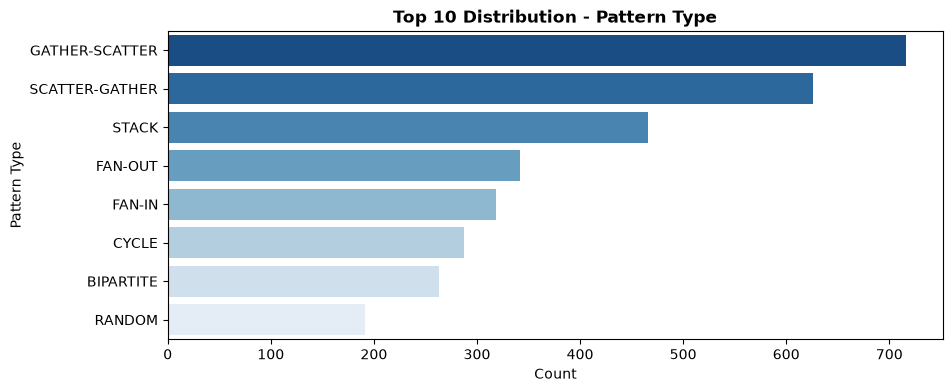

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
ACH        3208
Bitcoin       1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


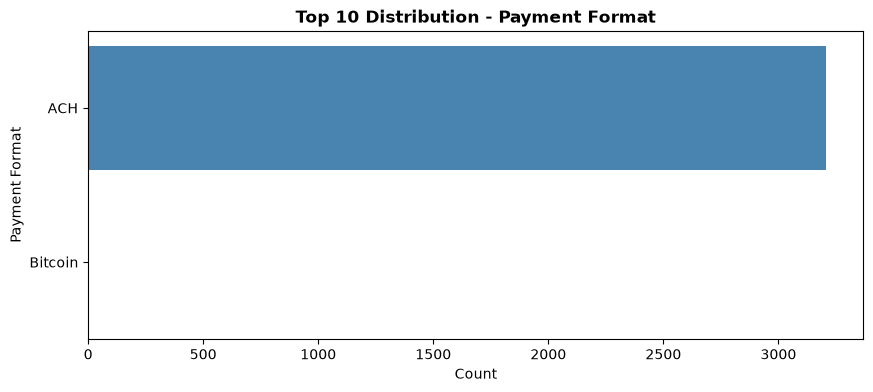

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar          1178
Euro                886
Saudi Riyal         336
Swiss Franc         114
Rupee               111
Yuan                107
Yen                  89
Canadian Dollar      76
Ruble                72
UK Pound             71
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


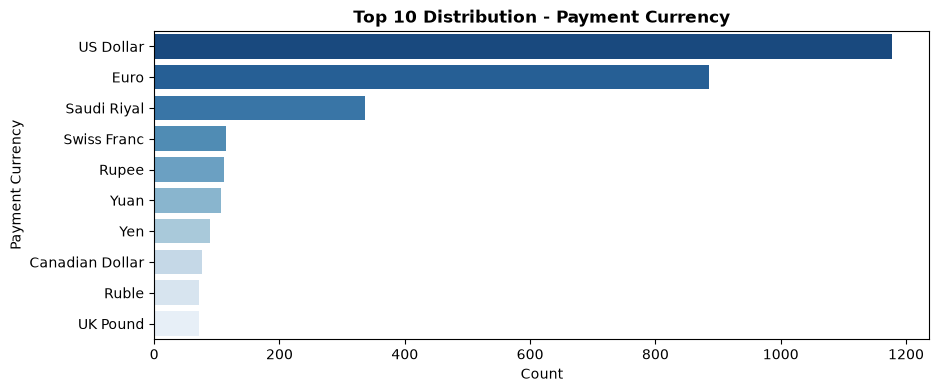

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar          1178
Euro                886
Saudi Riyal         336
Swiss Franc         114
Rupee               111
Yuan                107
Yen                  89
Canadian Dollar      76
Ruble                72
UK Pound             71
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


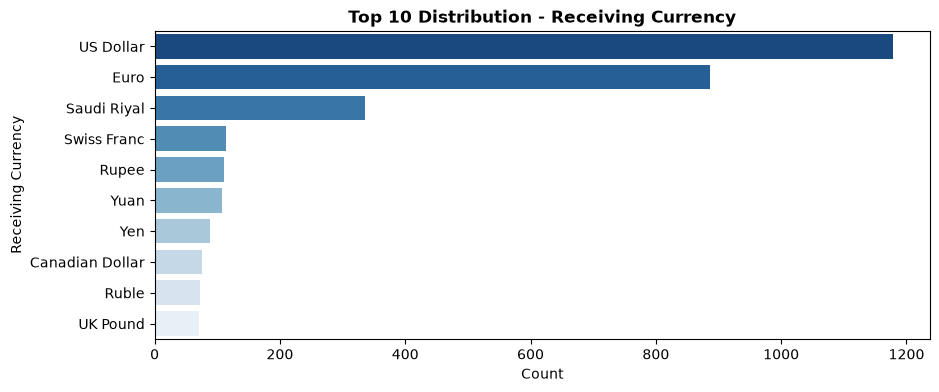

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
1    3209
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


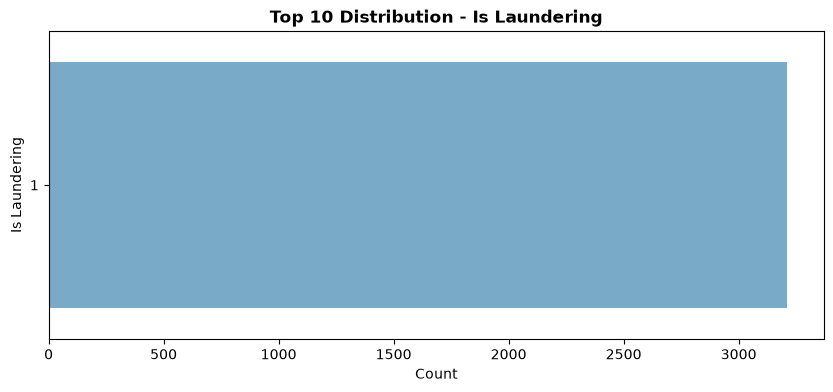

--------------------------------------------------


In [24]:
univariate_analysis(
    hi_small_patterns,
    categorical_cols=pattern_categorical_cols,
    numerical_cols=pattern_numerical_cols,
)


**Categorical balance:** `Pattern Type` is somewhat uneven across its 8 categories (largest: GATHER-SCATTER at 22.31%). `Payment Format` is imbalanced (ACH 99.97%); currency is moderately imbalanced (US Dollar 36.71%). `Is Laundering` cannot be balanced within this pattern-only data: every row is 1, so there are no legitimate examples.


#### 3.3.3 `li_medium_patterns` (LI-Medium Patterns)


In [25]:
display(inspect_dataset(li_medium_patterns, dataset_name="LI-Medium Patterns"))


Inspection Report: LI-Medium Patterns
Dataset Shape: 3,909 rows × 12 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 3909 entries, 0 to 3908
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           3909 non-null   str    
 1   From Bank           3909 non-null   str    
 2   From Account        3909 non-null   str    
 3   To Bank             3909 non-null   str    
 4   To Account          3909 non-null   str    
 5   Amount Received     3909 non-null   float64
 6   Receiving Currency  3909 non-null   str    
 7   Amount Paid         3909 non-null   float64
 8   Payment Currency    3909 non-null   str    
 9   Payment Format      3909 non-null   str    
 10  Is Laundering       3909 non-null   int64  
 11  Pattern Type        3909 non-null   str    
dtypes: float64(2), int64(1), str(9)
memory usage: 366.6 KB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,str,0,0.0,3592,2022/09/01 00:29
From Bank,str,0,0.0,1230,0110994
From Account,str,0,0.0,2719,80A0ECCF0
To Bank,str,0,0.0,1242,0110320
To Account,str,0,0.0,2821,804F34520
Amount Received,float64,0,0.0,3767,311.9
Receiving Currency,str,0,0.0,14,Euro
Amount Paid,float64,0,0.0,3767,311.9
Payment Currency,str,0,0.0,14,Euro
Payment Format,str,0,0.0,2,ACH


**Inspection summary:** LI-Medium Patterns contains 3,909 rows and 12 columns, with no missing values or duplicate rows. It has 8 pattern types. Timestamps are stored as text and should be parsed as datetime for time-based analysis; bank/account IDs remain strings to preserve identifier formatting.


=== Numerical Feature Summary ===


,Amount Received,Amount Paid
count,3.909000e+03,3.909000e+03
mean,5.149007e+07,5.149007e+07
std,1.335281e+09,1.335281e+09
min,1.500000e-01,1.500000e-01
25%,6.032410e+03,6.032410e+03
50%,1.187990e+04,1.187990e+04
75%,1.952677e+04,1.952677e+04
max,5.301076e+10,5.301076e+10




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Pattern Type**


Pattern Type
SCATTER-GATHER    886
STACK             615
GATHER-SCATTER    541
FAN-OUT           489
BIPARTITE         488
FAN-IN            329
CYCLE             283
RANDOM            278
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


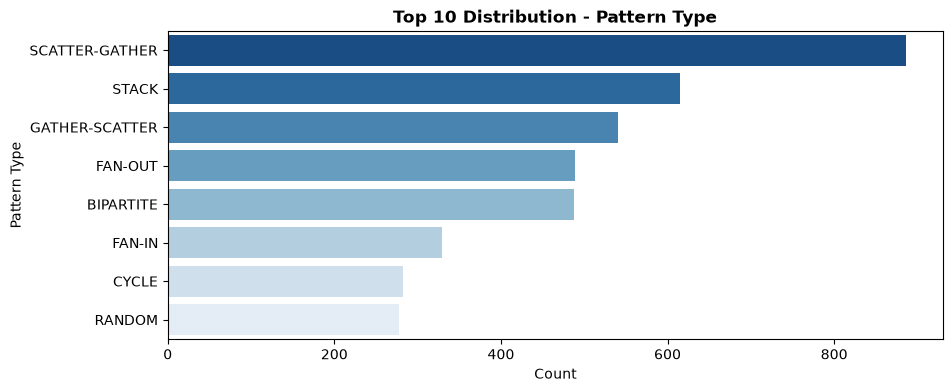

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
ACH        3908
Bitcoin       1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


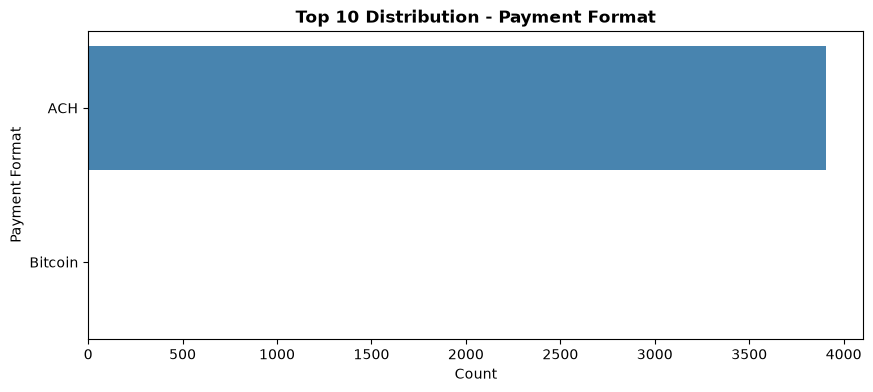

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            1560
Euro                 1225
Yuan                  229
Yen                   203
Ruble                 197
Rupee                 170
Canadian Dollar       115
UK Pound              110
Australian Dollar      58
Shekel                 38
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


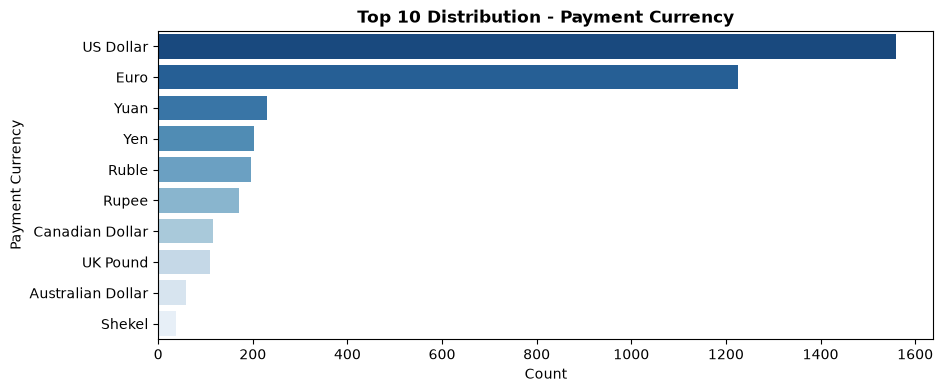

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            1560
Euro                 1225
Yuan                  229
Yen                   203
Ruble                 197
Rupee                 170
Canadian Dollar       115
UK Pound              110
Australian Dollar      58
Shekel                 38
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


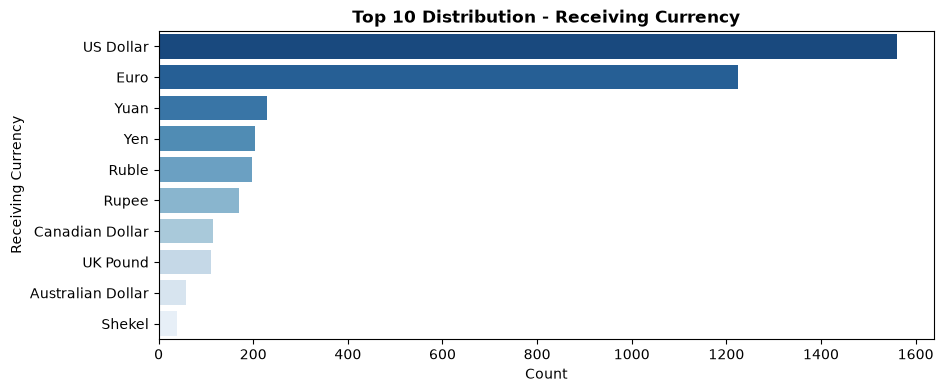

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
1    3909
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


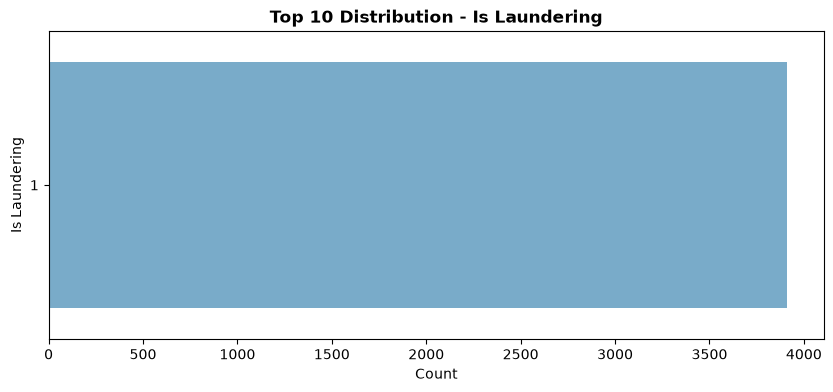

--------------------------------------------------


In [26]:
univariate_analysis(
    li_medium_patterns,
    categorical_cols=pattern_categorical_cols,
    numerical_cols=pattern_numerical_cols,
)


**Categorical balance:** `Pattern Type` is somewhat uneven across its 8 categories (largest: SCATTER-GATHER at 22.67%). `Payment Format` is imbalanced (ACH 99.97%); currency is moderately imbalanced (US Dollar 39.91%). `Is Laundering` cannot be balanced within this pattern-only data: every row is 1, so there are no legitimate examples.


#### 3.3.4 `li_small_patterns` (LI-Small Patterns)


In [27]:
display(inspect_dataset(li_small_patterns, dataset_name="LI-Small Patterns"))


Inspection Report: LI-Small Patterns
Dataset Shape: 1,023 rows × 12 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           1023 non-null   str    
 1   From Bank           1023 non-null   str    
 2   From Account        1023 non-null   str    
 3   To Bank             1023 non-null   str    
 4   To Account          1023 non-null   str    
 5   Amount Received     1023 non-null   float64
 6   Receiving Currency  1023 non-null   str    
 7   Amount Paid         1023 non-null   float64
 8   Payment Currency    1023 non-null   str    
 9   Payment Format      1023 non-null   str    
 10  Is Laundering       1023 non-null   int64  
 11  Pattern Type        1023 non-null   str    
dtypes: float64(2), int64(1), str(9)
memory usage: 96.0 KB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,str,0,0.0,983,2022/09/01 02:38
From Bank,str,0,0.0,190,001812
From Account,str,0,0.0,712,80279F810
To Bank,str,0,0.0,199,0110
To Account,str,0,0.0,804,8000A94C0
Amount Received,float64,0,0.0,981,10154.74
Receiving Currency,str,0,0.0,15,Australian Dollar
Amount Paid,float64,0,0.0,981,10154.74
Payment Currency,str,0,0.0,15,Australian Dollar
Payment Format,str,0,0.0,2,ACH


**Inspection summary:** LI-Small Patterns contains 1,023 rows and 12 columns, with no missing values or duplicate rows. It has 8 pattern types. Timestamps are stored as text and should be parsed as datetime for time-based analysis; bank/account IDs remain strings to preserve identifier formatting.


=== Numerical Feature Summary ===


,Amount Received,Amount Paid
count,1.023000e+03,1.023000e+03
mean,3.921572e+06,3.921572e+06
std,6.716403e+07,6.716403e+07
min,6.000000e-02,6.000000e-02
25%,4.311585e+03,4.311585e+03
50%,9.175320e+03,9.175320e+03
75%,1.471589e+04,1.471589e+04
max,1.927898e+09,1.927898e+09




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Pattern Type**


Pattern Type
SCATTER-GATHER    182
STACK             180
GATHER-SCATTER    150
FAN-OUT           149
BIPARTITE         129
CYCLE              83
RANDOM             77
FAN-IN             73
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


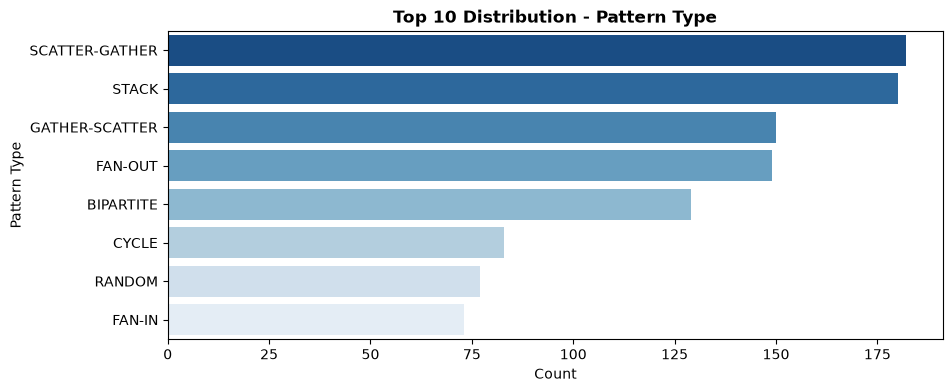

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
ACH        1022
Bitcoin       1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


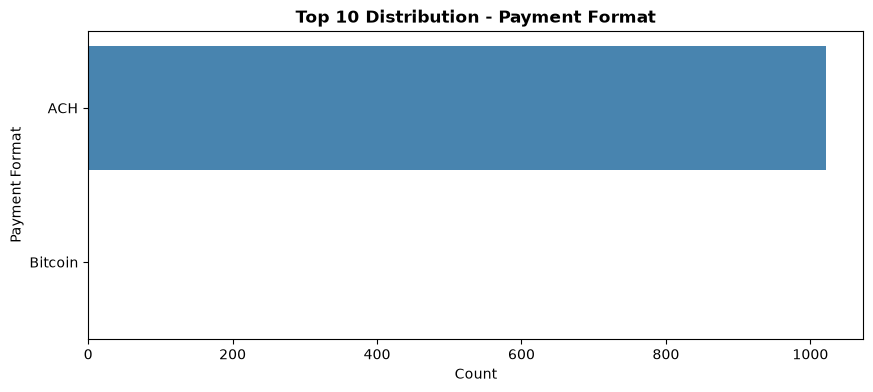

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            541
Euro                 414
Yuan                  19
Yen                   12
Australian Dollar     11
Canadian Dollar        7
Swiss Franc            4
Brazil Real            3
Rupee                  3
Mexican Peso           2
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


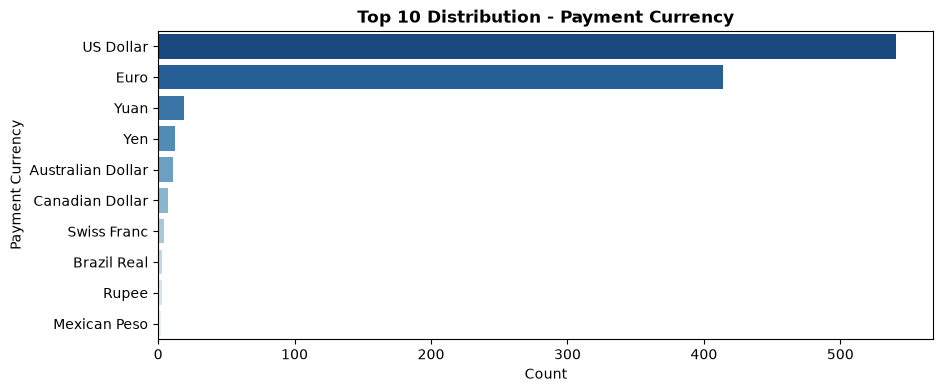

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            541
Euro                 414
Yuan                  19
Yen                   12
Australian Dollar     11
Canadian Dollar        7
Swiss Franc            4
Brazil Real            3
Rupee                  3
Mexican Peso           2
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


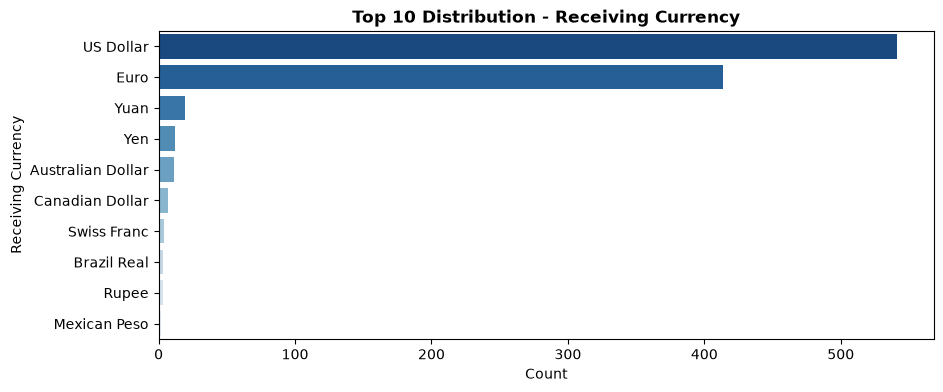

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
1    1023
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


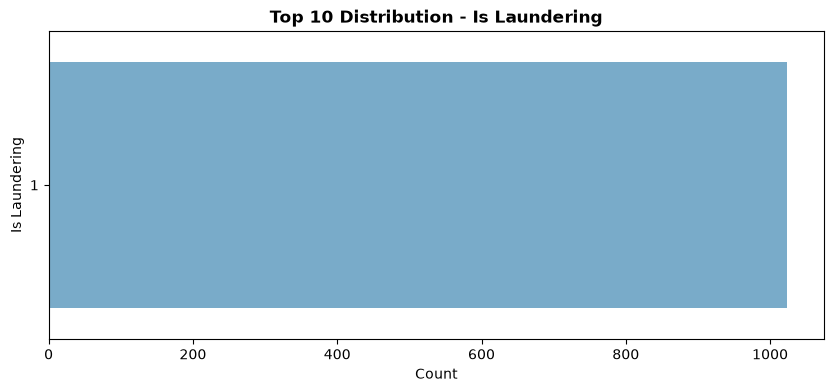

--------------------------------------------------


In [28]:
univariate_analysis(
    li_small_patterns,
    categorical_cols=pattern_categorical_cols,
    numerical_cols=pattern_numerical_cols,
)


**Categorical balance:** `Pattern Type` is relatively well spread across its 8 categories (largest: SCATTER-GATHER at 17.79%), though not perfectly uniform. `Payment Format` is imbalanced (ACH 99.90%); currency is moderately imbalanced (US Dollar 52.88%). `Is Laundering` cannot be balanced within this pattern-only data: every row is 1, so there are no legitimate examples.


**Combining pattern datasets:** It may make sense to combine the four pattern datasets into one larger dataset, adding a `Type` column to record each row's source: `hi_small`, `li_small`, `hi_medium`, or `li_medium`. This would support combined pattern analysis while preserving each row's source dataset.


### 3.4 Dataset Inspection Insights

#### 3.4.1 Summary of Findings

**Accounts:** All four account datasets have no missing values or duplicate rows. `Account Number` and `Entity ID` are alphanumeric identifiers and should remain strings, not be converted to integers. Bank and entity categories are high-cardinality and broadly distributed, with no single category dominating.

**Transactions:** The first 100,000 rows of each transaction dataset contain no missing values or duplicate rows. Parse `Timestamp` as a datetime before time-based analysis, while keeping account identifiers as strings. The samples are categorically imbalanced: Reinvestment dominates payment format, US Dollar dominates both currency fields, and laundering represents only 0.001%-0.005% of each sample. Treat these prevalence values as sample-based, not full-dataset rates.

**Patterns:** Each pattern dataset contains eight pattern types, distributed more evenly than payment format or currency. ACH accounts for at least 99.90% of payment formats, and every pattern row is labelled as laundering. Therefore, the pattern datasets alone do not provide legitimate examples for binary classification.

**Combining datasets:** It may be useful to combine datasets within each category: accounts, transactions, and patterns, and add a `Type` column with values `hi_small`, `li_small`, `hi_medium`, or `li_medium` to preserve each row's source. Before joining accounts to transactions, verify identifier-key alignment and normalize timestamp types.


#### 3.4.2 Future Steps

**Preprocessing:** Use the transaction data as the central dataset: each row represents a transfer, and `Is Laundering` is its target label. Link sender details using `From Bank` and `Account`, and receiver details using `To Bank` and `Account.1`; match these to `Bank ID` and `Account Number` in the account data. Keep identifiers as strings, standardize their formatting, and retain the dataset `Type` to prevent accidental cross-source matches. Add sender and receiver metadata separately. `Entity ID` can group accounts belonging to one entity, but should not be used alone as the account join key. Use pattern files to understand suspicious sequences (such as cycles, fan-in, and fan-out), but do not simply append their rows to the transaction data: patterns contain laundering examples only, which would distort class balance. Avoid using pattern-derived labels as input features when they reveal the target, to prevent target leakage.

**Feature engineering:** After linking the account metadata, derive transaction and account activity features, including amounts and currencies, the difference between amounts paid and received, sender and receiver transaction counts and totals over time windows, numbers of distinct counterparties, how quickly funds move onward, unusually high inbound or outbound activity, and whether transactions form cycles or resemble fan-in/fan-out. These features add behavioral context beyond an individual transfer and can then be used by a model or rules-based detector.


### 4. Transaction Volume Velocity Over Time

Inspecting transaction timestamps to detect hourly, daily, and velocity patterns.

In [29]:
print(hi_small_trans['Timestamp'].min(), hi_small_trans['Timestamp'].max()) 
print(li_small_trans['Timestamp'].min(), hi_small_trans['Timestamp'].max())

2022/09/01 00:00 2022/09/01 00:29
2022/09/01 00:00 2022/09/01 00:29


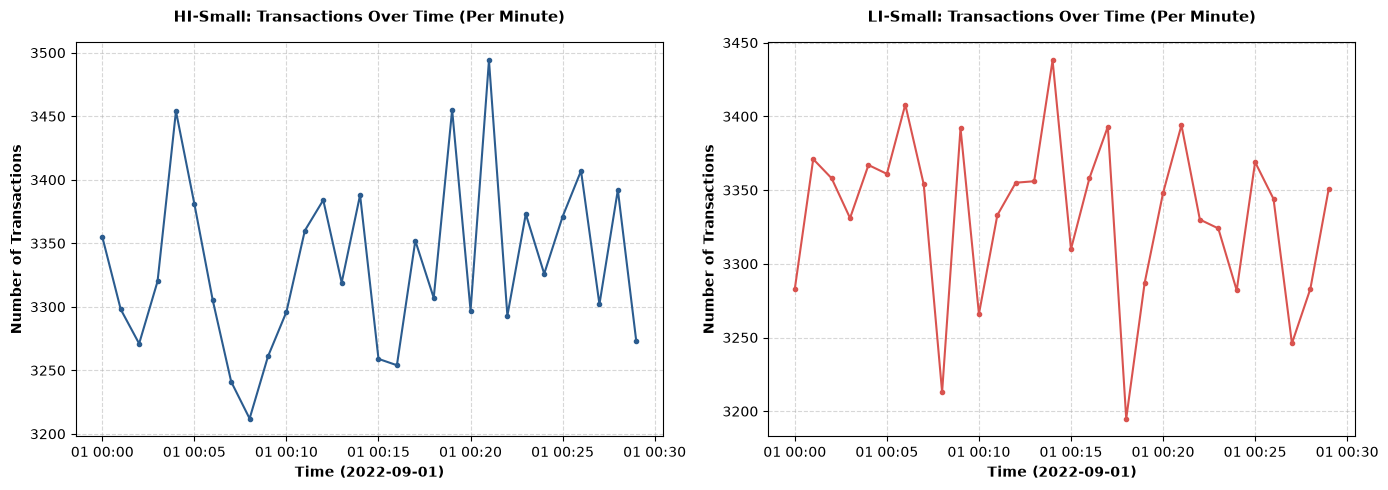

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Garantir que a coluna Timestamp está em formato datetime
hi_small_trans['Timestamp'] = pd.to_datetime(hi_small_trans['Timestamp'])
li_small_trans['Timestamp'] = pd.to_datetime(li_small_trans['Timestamp'])

# Agrupar por minuto ('min') para ver a evolução nos 30 minutos da amostra
hi_minutely = hi_small_trans.set_index('Timestamp').resample('min').size()
li_minutely = li_small_trans.set_index('Timestamp').resample('min').size()

# Criar a figura com dois subgráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: HI-Small ---
ax[0].plot(hi_minutely.index, hi_minutely.values, color='#2b5c8f', linewidth=1.5, marker='o', markersize=3)
ax[0].set_title('HI-Small: Transactions Over Time (Per Minute)', fontsize=11, fontweight='bold', pad=15)
ax[0].set_xlabel('Time (2022-09-01)', fontsize=10, fontweight='bold')
ax[0].set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.5)

# --- Gráfico 2: LI-Small ---
ax[1].plot(li_minutely.index, li_minutely.values, color='#d9534f', linewidth=1.5, marker='o', markersize=3)
ax[1].set_title('LI-Small: Transactions Over Time (Per Minute)', fontsize=11, fontweight='bold', pad=15)
ax[1].set_xlabel('Time (2022-09-01)', fontsize=10, fontweight='bold')
ax[1].set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### Transaction Volume Velocity Over Time Insights

The transaction volume remains relatively stable throughout the 30 minutes analyzed, consistently fluctuating within a predictable range of 3,200 to 3,500 transactions per minute. There are no abrupt interruptions or extreme traffic spikes, indicating a continuous and uniform flow within the data sample. Furthermore, both datasets (HI-Small and LI-Small) exhibit very similar pacing behavior.


### 5. Payment Channel Analysis 

Evaluating volume and risk distribution across payment formats (Wire, ACH, Cheque, Credit Card, Reinvestment, etc.).

,Total_Transactions,Laundering_Count,Laundering_Rate_Pct
Payment Format,,,
Cash,2668,1,0.0375
Credit Card,9028,2,0.0222
Cheque,9393,2,0.0213
Bitcoin,30,0,0.0000
ACH,4436,0,0.0000
Reinvestment,73296,0,0.0000
Wire,1149,0,0.0000


C:\Users\almad\AppData\Local\Temp\ipykernel_13336\374739332.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=format_stats.index, y=format_stats['Total_Transactions'], ax=ax[0], palette='Blues_r')
C:\Users\almad\AppData\Local\Temp\ipykernel_13336\374739332.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)
C:\Users\almad\AppData\Local\Temp\ipykernel_13336\374739332.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=format_stats.index, y=format_stats['Laundering_Rate_Pct'], ax=ax[1], palette='Reds_r')
C

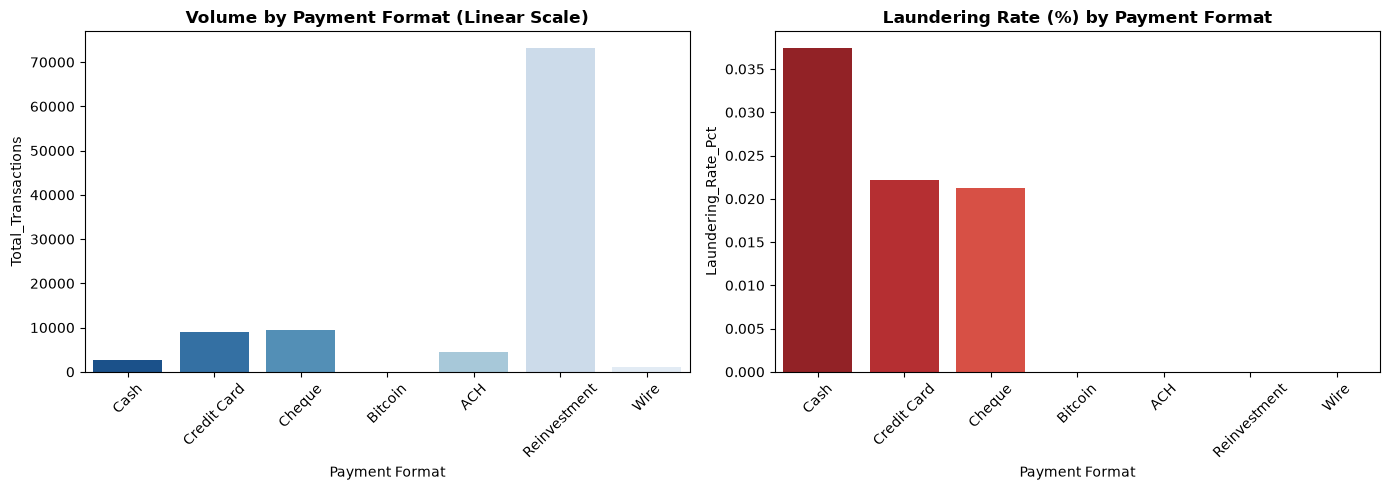

In [31]:
# Read-only format risk summary
format_stats = hi_small_trans.groupby('Payment Format').agg(
    Total_Transactions=('Is Laundering', 'count'),
    Laundering_Count=('Is Laundering', 'sum'),
    Laundering_Rate_Pct=('Is Laundering', lambda x: (x.sum() / len(x)) * 100)
).sort_values(by='Laundering_Rate_Pct', ascending=False)

display(format_stats.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Total Volume by Payment Format (Escala linear, sem transformações)
sns.barplot(x=format_stats.index, y=format_stats['Total_Transactions'], ax=ax[0], palette='Blues_r')
ax[0].set_title('Volume by Payment Format (Linear Scale)', fontsize=12, fontweight='bold')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

# Laundering Rate by Payment Format
sns.barplot(x=format_stats.index, y=format_stats['Laundering_Rate_Pct'], ax=ax[1], palette='Reds_r')
ax[1].set_title('Laundering Rate (%) by Payment Format', fontsize=12, fontweight='bold')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

#### Payment Channel Analysis Insights

In the first 100,000 HI-Small transaction rows, there are 5 laundering transactions. Cash has the highest observed laundering rate (0.0375%); Credit Card and Cheque each have 2 flagged transactions. No flagged rows appear for ACH, Bitcoin, Reinvestment, or Wire in this sample. These sample results should not be interpreted as full-dataset rates.


### 6. Inter-Bank vs. Intra-Bank Laundering Distribution Analysis

Inspecting inter and intra-bank relationships.

In [32]:
# Compare laundering counts for same-bank and cross-bank transactions in the loaded sample.
interbank_table = (
    hi_small_trans.assign(
        Relationship=np.where(
            hi_small_trans["From Bank"].eq(hi_small_trans["To Bank"]),
            "Intra-Bank (Same Bank)",
            "Inter-Bank (Different Banks)",
        )
    )
    .groupby("Relationship")["Is Laundering"]
    .agg(Total="size", Laundering="sum")
)

total_laundering_cases = interbank_table["Laundering"].sum()
interbank_table["Laundering(%)"] = (
    interbank_table["Laundering"] / total_laundering_cases * 100
    if total_laundering_cases
    else 0
)

display(interbank_table[["Total", "Laundering", "Laundering(%)"]].round(4))


,Total,Laundering,Laundering(%)
Relationship,,,
Inter-Bank (Different Banks),26207,5,100.0
Intra-Bank (Same Bank),73793,0,0.0


In the first 100,000 HI-Small transaction rows, all 5 flagged laundering transactions are inter-bank; none are intra-bank. The sample contains 26,207 inter-bank and 73,793 intra-bank transactions. This describes the loaded sample only, not the full dataset.


### 7. Dataset Consolidation

Combine datasets of the same kind and retain their source in a `Type` column. Account and pattern inputs below are complete datasets; transaction dataframes contain the first 100,000 rows from each source, so `transactions_all` is a combined sample rather than the full transaction data.


#### 7.1 Combined Accounts Dataset


In [38]:
accounts_all = pd.concat(
    [
        hi_small_accounts.assign(Type="hi_small"),
        li_small_accounts.assign(Type="li_small"),
        hi_medium_accounts.assign(Type="hi_medium"),
        li_medium_accounts.assign(Type="li_medium"),
    ],
    ignore_index=True,
)

print(f"Combined accounts shape: {accounts_all.shape}")
display(accounts_all.head())


Combined accounts shape: (5359878, 6)


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name,Type
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438,hi_small
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520,hi_small
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397,hi_small
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813,hi_small
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889,hi_small


In [39]:
# Accounts have no Is Laundering target; show the row balance by source dataset.
account_source_balance = accounts_all["Type"].value_counts().sort_index().rename("Count").to_frame()
account_source_balance["Percentage"] = (account_source_balance["Count"] / len(accounts_all) * 100).round(2)
display(account_source_balance)


,Count,Percentage
Type,,
hi_medium,2087786,38.95
hi_small,518581,9.68
li_medium,2040823,38.08
li_small,712688,13.30


**Interpretation:** The account data has no `Is Laundering` label, so these percentages describe the source mix rather than a target-class balance. The two medium sources contribute about 77% of the 5.36 million accounts combined, while the two small sources contribute about 23%; the combined account table is therefore weighted toward medium-source records.

In [44]:
account_source_class_counts = transactions_all["Is Laundering"].value_counts(dropna=False).sort_index()
transaction_class_balance = pd.DataFrame({
    "Count": account_source_class_counts,
    "Percentage": (account_source_class_counts / len(transactions_all) * 100).round(4),
})
display(transaction_class_balance)

display(pd.crosstab(
    transactions_all["Type"],
    transactions_all["Is Laundering"],
    margins=True,
    margins_name="Total",
))


,Count,Percentage
Is Laundering,,
0,399988,99.997
1,12,0.003


Is Laundering,0,1,Total
Type,,,
hi_medium,99999,1,100000
hi_small,99995,5,100000
li_medium,99997,3,100000
li_small,99997,3,100000
Total,399988,12,400000


#### 7.2 Combined Transactions Dataset


In [34]:
transactions_all = pd.concat(
    [
        hi_small_trans.assign(Type="hi_small"),
        li_small_trans.assign(Type="li_small"),
        hi_medium_trans.assign(Type="hi_medium"),
        li_medium_trans.assign(Type="li_medium"),
    ],
    ignore_index=True,
)

print(f"Combined transaction sample shape: {transactions_all.shape}")
display(transactions_all.head())


Combined transaction sample shape: (400000, 12)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Type
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,hi_small
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,hi_small
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,hi_small
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,hi_small
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,hi_small


In [40]:
transaction_class_counts = transactions_all["Is Laundering"].value_counts(dropna=False).sort_index()
transaction_class_balance = pd.DataFrame({
    "Count": transaction_class_counts,
    "Percentage": (transaction_class_counts / len(transactions_all) * 100).round(4),
})
display(transaction_class_balance)

display(pd.crosstab(
    transactions_all["Type"],
    transactions_all["Is Laundering"],
    margins=True,
    margins_name="Total",
))


,Count,Percentage
Is Laundering,,
0,399988,99.997
1,12,0.003


Is Laundering,0,1,Total
Type,,,
hi_medium,99999,1,100000
hi_small,99995,5,100000
li_medium,99997,3,100000
li_small,99997,3,100000
Total,399988,12,400000


**Interpretation:** The combined transaction sample is severely imbalanced: only 12 of 400,000 rows (0.003%) are labeled laundering, compared with 399,988 non-laundering rows (99.997%). Each source contributes 100,000 sampled rows, with between 1 and 5 positive examples per source. A model that predicts only the majority class could appear highly accurate while missing the laundering cases, so accuracy alone would be misleading. These proportions describe the loaded samples, not the full transaction files.

#### 7.3 Combined Patterns Dataset


In [35]:
patterns_all = pd.concat(
    [
        hi_small_patterns.assign(Type="hi_small"),
        li_small_patterns.assign(Type="li_small"),
        hi_medium_patterns.assign(Type="hi_medium"),
        li_medium_patterns.assign(Type="li_medium"),
    ],
    ignore_index=True,
)

print(f"Combined patterns shape: {patterns_all.shape}")
display(patterns_all.head())


Combined patterns shape: (30884, 13)


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Pattern Type,Type
0,2022/09/01 00:06,021174,800737690,012,80011F990,2848.96,Euro,2848.96,Euro,ACH,1,FAN-OUT,hi_small
1,2022/09/01 04:33,021174,800737690,020,80020C5B0,8630.40,Euro,8630.40,Euro,ACH,1,FAN-OUT,hi_small
2,2022/09/01 09:14,021174,800737690,020,80006A5E0,35642.49,Yuan,35642.49,Yuan,ACH,1,FAN-OUT,hi_small
3,2022/09/01 09:56,021174,800737690,00220,8007A5B70,5738987.96,US Dollar,5738987.96,US Dollar,ACH,1,FAN-OUT,hi_small
4,2022/09/01 11:28,021174,800737690,001244,80093C0D0,7254.53,US Dollar,7254.53,US Dollar,ACH,1,FAN-OUT,hi_small


In [41]:
pattern_class_counts = patterns_all["Is Laundering"].value_counts(dropna=False).sort_index()
pattern_class_balance = pd.DataFrame({
    "Count": pattern_class_counts,
    "Percentage": (pattern_class_counts / len(patterns_all) * 100).round(4),
})
display(pattern_class_balance)

display(patterns_all["Pattern Type"].value_counts(dropna=False).rename("Count").to_frame())
display(pd.crosstab(
    patterns_all["Type"],
    patterns_all["Is Laundering"],
    margins=True,
    margins_name="Total",
))


,Count,Percentage
Is Laundering,,
1,30884,100.0


,Count
Pattern Type,
GATHER-SCATTER,5696
SCATTER-GATHER,5682
STACK,5247
FAN-OUT,3108
FAN-IN,3035
BIPARTITE,3015
CYCLE,2888
RANDOM,2213


Is Laundering,1,Total
Type,,
hi_medium,22743,22743
hi_small,3209,3209
li_medium,3909,3909
li_small,1023,1023
Total,30884,30884


**Interpretation:** All 30,884 rows in the patterns dataset are labeled laundering. This is expected for a dataset of identified laundering patterns, but it does not represent the natural class balance of all transactions and cannot by itself provide both classes for binary classification. The pattern-type counts describe the mix of detected patterns, not the laundering-versus-legitimate balance.

#### 7.4 Link Accounts to Transactions and Check Class Balance

Join sender and receiver account metadata separately. Match senders on `Type`, `From Bank`, and `Account`; match receivers on `Type`, `To Bank`, and `Account.1`. These correspond to `Type`, `Bank ID`, and `Account Number` in `accounts_all`. Keys are standardized as trimmed strings for matching, while the original transaction columns remain unchanged. The left joins preserve every transaction row; unmatched account details remain missing and are counted below. The final linked transaction dataset is named `data`; the class balance and plot below summarize all rows currently loaded, which are 100,000 transaction samples per source.


In [36]:
# Preserve the combined transaction rows and prepare normalized string keys.
transactions_with_accounts = transactions_all.copy()
transactions_with_accounts["_type_key"] = transactions_with_accounts["Type"].astype("string").str.strip()
transactions_with_accounts["_sender_bank_key"] = transactions_with_accounts["From Bank"].astype("string").str.strip()
transactions_with_accounts["_sender_account_key"] = transactions_with_accounts["Account"].astype("string").str.strip()
transactions_with_accounts["_receiver_bank_key"] = transactions_with_accounts["To Bank"].astype("string").str.strip()
transactions_with_accounts["_receiver_account_key"] = transactions_with_accounts["Account.1"].astype("string").str.strip()

# Restrict joins to each source dataset and use the bank/account pair as the key.
account_lookup = accounts_all[
    ["Type", "Bank ID", "Account Number", "Bank Name", "Entity ID", "Entity Name"]
].copy()
account_lookup["_type_key"] = account_lookup["Type"].astype("string").str.strip()
account_lookup["_bank_key"] = account_lookup["Bank ID"].astype("string").str.strip()
account_lookup["_account_key"] = account_lookup["Account Number"].astype("string").str.strip()

sender_lookup = account_lookup[
    ["_type_key", "_bank_key", "_account_key", "Bank Name", "Entity ID", "Entity Name"]
].rename(columns={
    "_bank_key": "_sender_bank_key",
    "_account_key": "_sender_account_key",
    "Bank Name": "Sender Bank Name",
    "Entity ID": "Sender Entity ID",
    "Entity Name": "Sender Entity Name",
})
receiver_lookup = account_lookup[
    ["_type_key", "_bank_key", "_account_key", "Bank Name", "Entity ID", "Entity Name"]
].rename(columns={
    "_bank_key": "_receiver_bank_key",
    "_account_key": "_receiver_account_key",
    "Bank Name": "Receiver Bank Name",
    "Entity ID": "Receiver Entity ID",
    "Entity Name": "Receiver Entity Name",
})

original_row_count = len(transactions_all)
original_rows_by_type = transactions_all.groupby("Type", observed=True).size().sort_index()

transactions_with_accounts = transactions_with_accounts.merge(
    sender_lookup,
    left_on=["_type_key", "_sender_bank_key", "_sender_account_key"],
    right_on=["_type_key", "_sender_bank_key", "_sender_account_key"],
    how="left",
    validate="many_to_one",
    indicator="_sender_merge",
)
transactions_with_accounts["Sender Account Matched"] = transactions_with_accounts["_sender_merge"].eq("both")
transactions_with_accounts = transactions_with_accounts.drop(columns="_sender_merge")

transactions_with_accounts = transactions_with_accounts.merge(
    receiver_lookup,
    left_on=["_type_key", "_receiver_bank_key", "_receiver_account_key"],
    right_on=["_type_key", "_receiver_bank_key", "_receiver_account_key"],
    how="left",
    validate="many_to_one",
    indicator="_receiver_merge",
)
transactions_with_accounts["Receiver Account Matched"] = transactions_with_accounts["_receiver_merge"].eq("both")
transactions_with_accounts = transactions_with_accounts.drop(
    columns=["_receiver_merge", "_type_key", "_sender_bank_key", "_sender_account_key", "_receiver_bank_key", "_receiver_account_key"]
)

if len(transactions_with_accounts) != original_row_count:
    raise AssertionError(
        f"Account joins changed the transaction row count: {original_row_count} -> {len(transactions_with_accounts)}"
    )

rows_by_type_after = transactions_with_accounts.groupby("Type", observed=True).size().sort_index()
if not original_rows_by_type.equals(rows_by_type_after):
    raise AssertionError("Account joins changed the transaction row count for at least one source Type")

sender_missing = int((~transactions_with_accounts["Sender Account Matched"]).sum())
receiver_missing = int((~transactions_with_accounts["Receiver Account Matched"]).sum())
print(f"Transaction rows before joins: {original_row_count:,}")
print(f"Transaction rows after joins:  {len(transactions_with_accounts):,}")
print(f"Rows preserved by Type: {original_rows_by_type.to_dict() == rows_by_type_after.to_dict()}")
print(f"Sender accounts without a match: {sender_missing:,}")
print(f"Receiver accounts without a match: {receiver_missing:,}")
print("Missing joined sender metadata:")
display(transactions_with_accounts[["Sender Bank Name", "Sender Entity ID", "Sender Entity Name"]].isna().sum().rename("Missing values"))
print("Missing joined receiver metadata:")
display(transactions_with_accounts[["Receiver Bank Name", "Receiver Entity ID", "Receiver Entity Name"]].isna().sum().rename("Missing values"))
display(transactions_with_accounts.head())


Transaction rows before joins: 400,000
Transaction rows after joins:  400,000
Rows preserved by Type: True
Sender accounts without a match: 0
Receiver accounts without a match: 0
Missing joined sender metadata:


Sender Bank Name      0
Sender Entity ID      0
Sender Entity Name    0
Name: Missing values, dtype: int64

Missing joined receiver metadata:


Receiver Bank Name      0
Receiver Entity ID      0
Receiver Entity Name    0
Name: Missing values, dtype: int64

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Type,Sender Bank Name,Sender Entity ID,Sender Entity Name,Sender Account Matched,Receiver Bank Name,Receiver Entity ID,Receiver Entity Name,Receiver Account Matched
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,hi_small,National Bank of Laramie,800D232D0,Partnership #1,True,National Bank of Laramie,800D232D0,Partnership #1,True
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,hi_small,Sappo Cooperative Bank,8008EEA70,Partnership #2,True,Arbor Savings Bank,800AA5D20,Corporation #1,True
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,hi_small,National Bank of Fort Wayne,800FBB3A0,Partnership #3,True,National Bank of Fort Wayne,800FBB3A0,Partnership #3,True
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,hi_small,National Bank of the East,800C0EF20,Sole Proprietorship #1,True,National Bank of the East,800C0EF20,Sole Proprietorship #1,True
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,hi_small,National Bank of Laramie,800C3EC10,Partnership #4,True,National Bank of Laramie,800C3EC10,Partnership #4,True


In [42]:
data = transactions_with_accounts.copy()

class_counts = data["Is Laundering"].value_counts(dropna=False).sort_index()
class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage": (class_counts / len(data) * 100).round(4),
})
display(class_balance)

display(pd.crosstab(
    data["Type"],
    data["Is Laundering"],
    margins=True,
    margins_name="Total",
))

ax = class_counts.plot(kind="bar", figsize=(7, 4), color="steelblue")
ax.set_title("Class Balance in the Linked Transaction Dataset")
ax.set_xlabel("Is Laundering")
ax.set_ylabel("Number of transactions")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


,Count,Percentage
Is Laundering,,
0,399988,99.997
1,12,0.003


Is Laundering,0,1,Total
Type,,,
hi_medium,99999,1,100000
hi_small,99995,5,100000
li_medium,99997,3,100000
li_small,99997,3,100000
Total,399988,12,400000


**Interpretation:** The join preserved all 400,000 transaction rows, and every sender and receiver account matched. The linked dataset therefore has the same class balance as the transaction sample in 7.2: 399,988 non-laundering rows (99.997%) and 12 laundering rows (0.003%). Linking account metadata did not add or remove examples or change the target labels. The class remains severely imbalanced, and these results apply to the loaded samples rather than the full transaction files.